In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [74]:
# Read CSV file
# file_path = '32130_AT2_25745973.csv'
file_path = './For Visualize/visualz.csv'
df = pd.read_csv(file_path, encoding='ascii')

Generating pairplot for attributes: ['age', 'height', 'weight', 'ap_lo', 'ap_hi']


<Figure size 1000x1000 with 0 Axes>

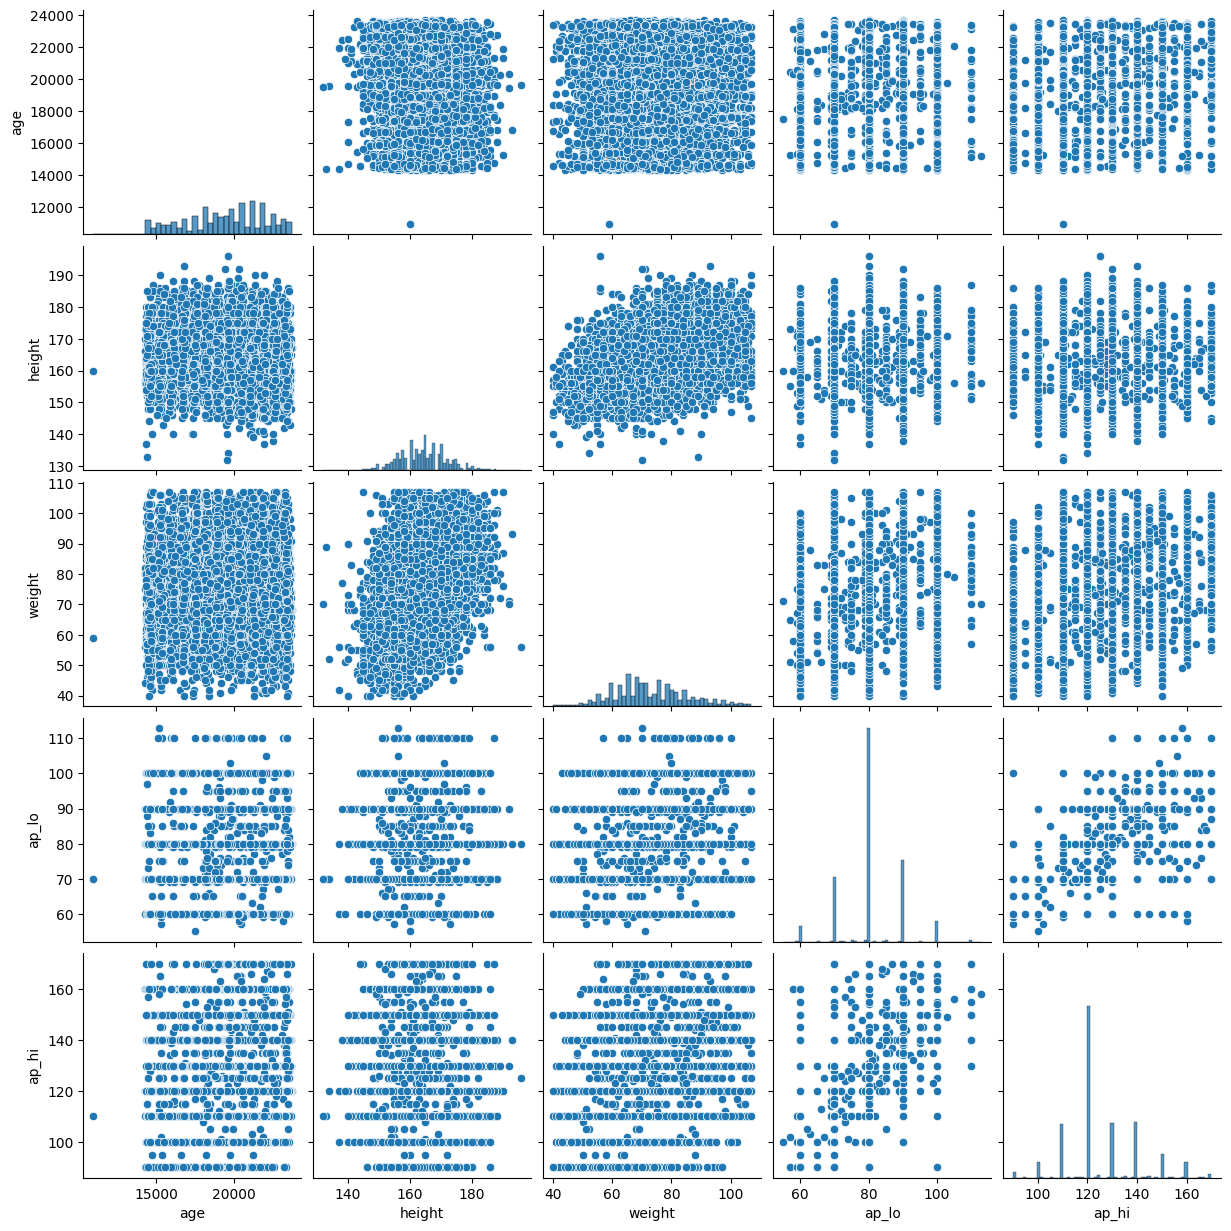

Generating correlation heatmap.


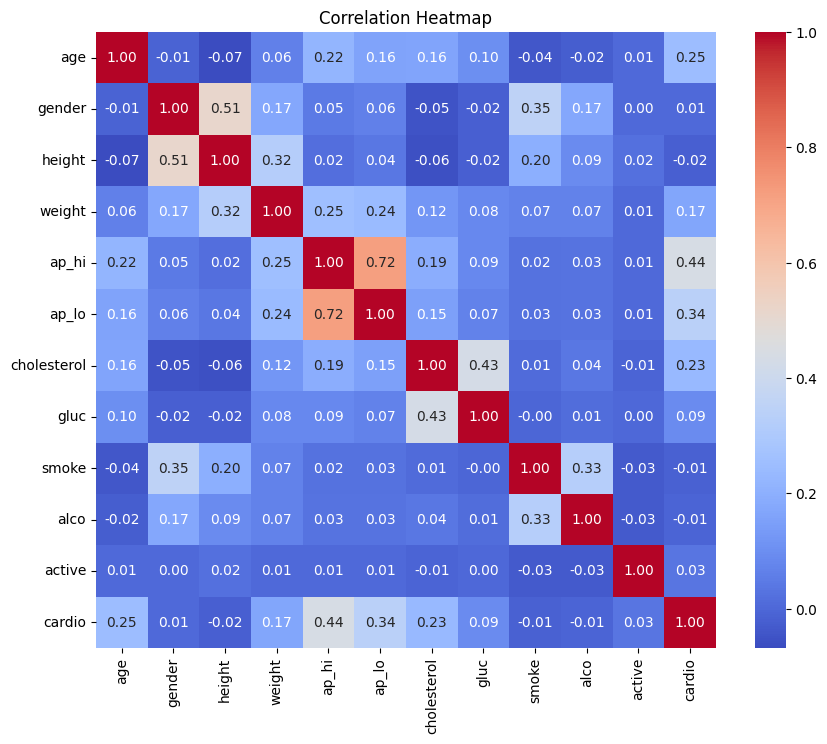

In [75]:
# Create scatterplot matrix for a subset of attributes
cols_for_pairplot = ['age', 'height', 'weight', 'ap_lo', 'ap_hi']
print('\
Generating pairplot for attributes:', cols_for_pairplot)
plt.figure(figsize=(10, 10))
pairplot = sns.pairplot(df[cols_for_pairplot])
plt.show()

# Heatmap for correlation among numeric variables
print('\
Generating correlation heatmap.')
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr('pearson')
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# # Select numerical columns for clustering (removing id and some possibly less interesting ones)
# clus_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
# scaler = StandardScaler()
# X = scaler.fit_transform(df[clus_cols])

# # Run k-means with k=3 clusters
# kmeans = KMeans(n_clusters=3, random_state=42)
# clusters = kmeans.fit_predict(X)
# df['cluster'] = clusters

# print('\
# Cluster counts:')
# print(df['cluster'].value_counts())

# # Visualize clusters on AP_hi vs AP_lo scatter plot
# plt.figure(figsize=(8, 6))
# plt.scatter(df['ap_hi'], df['ap_lo'], c=df['cluster'], cmap='viridis', alpha=0.5)
# plt.xlabel('ap_hi')
# plt.ylabel('ap_lo')
# plt.title('K-means clusters (k=3) on ap_hi vs ap_lo')
# plt.show()

# # Identify and highlight outliers in ap_hi and ap_lo
# # Using IQR method for ap_hi
# Q1 = df['ap_hi'].quantile(0.25)
# Q3 = df['ap_hi'].quantile(0.75)
# IQR = Q3 - Q1
# outliers_ap_hi = df[(df['ap_hi'] < Q1 - 1.5*IQR) | (df['ap_hi'] > Q3 + 1.5*IQR)]

# print('\
# Number of potential outliers in ap_hi:', outliers_ap_hi.shape[0])

# print('done')

In [78]:
# Recode cholesterol and gluc to categorical labels for further clustering insight
# Assuming: 1 for normal, 2 for above normal, 3 for well above normal
gender_map = {1: 'Female', 2:'Male'}
cholesterol_map = {1: 'normal', 2: 'above normal', 3: 'well above normal'}
gluc_map = {1: 'normal', 2: 'above normal', 3: 'well above normal'}
smoke_map = {0: 'No', 1: 'Yes'}
alco_map = {0: 'No', 1: 'Yes'}
active_map = {0: 'No', 1: 'Yes'}
cardio_map = {0: 'No', 1: 'Yes'}

df['gender_cat'] = df['gender'].map(gender_map)
df['cholesterol_cat'] = df['cholesterol'].map(cholesterol_map)
df['gluc_cat'] = df['gluc'].map(gluc_map)
df['smoke_cat'] = df['smoke'].map(smoke_map)
df['alco_cat'] = df['alco'].map(alco_map)
df['active_cat'] = df['active'].map(active_map)
df['cardio_cat'] = df['cardio'].map(cardio_map)

print('\
Value counts for gender categories:')
print(df['gender_cat'].value_counts())
print('\
Value counts for cholesterol categories:')
print(df['cholesterol_cat'].value_counts())
print('\
Value counts for gluc categories:')
print(df['gluc_cat'].value_counts())
print('\
Value counts for smoker categories:')
print(df['smoker_cat'].value_counts())
print('\
Value counts for alco categories:')
print(df['alco_cat'].value_counts())
print('\
Value counts for active categories:')
print(df['active_cat'].value_counts())
print('\
Value counts for cardio categories:')
print(df['cardio_cat'].value_counts())



Value counts for gender categories:
gender_cat
Female    6927
Male      3561
Name: count, dtype: int64
Value counts for cholesterol categories:
cholesterol_cat
normal               7918
above normal         1420
well above normal    1150
Name: count, dtype: int64
Value counts for gluc categories:
gluc_cat
normal               8929
well above normal     780
above normal          779
Name: count, dtype: int64
Value counts for smoker categories:
smoker_cat
No     9589
Yes     899
Name: count, dtype: int64
Value counts for alco categories:
alco_cat
No     9952
Yes     536
Name: count, dtype: int64
Value counts for active categories:
active_cat
No     8413
Yes    2075
Name: count, dtype: int64
Value counts for cardio categories:
cardio_cat
No     5420
Yes    5068
Name: count, dtype: int64


In [79]:
gender_map = {1: 'Female', 2:'Male'}
cholesterol_map = {1: 'normal', 2: 'above normal', 3: 'well above normal'}
gluc_map = {1: 'normal', 2: 'above normal', 3: 'well above normal'}
smoker_map = {0: 'No', 1: 'Yes'}
alco_map = {0: 'No', 1: 'Yes'}
active_map = {0: 'No', 1: 'Yes'}
cardio_map = {0: 'No', 1: 'Yes'}

df['gender'] = df['gender'].map(gender_map)
df['cholesterol'] = df['cholesterol'].map(cholesterol_map)
df['gluc'] = df['gluc'].map(gluc_map)
df['smoke'] = df['smoke'].map(smoker_map)
df['alco'] = df['alco'].map(alco_map)
df['active'] = df['active'].map(active_map)
df['cardio'] = df['cardio'].map(cardio_map)

In [80]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,gender_cat,cholesterol_cat,gluc_cat,smoker_cat,alco_cat,active_cat,cardio_cat,smoke_cat
0,16905,Female,171,60.0,120,70,normal,normal,No,No,No,No,Female,normal,normal,No,No,No,No,No
1,17571,Male,175,69.0,130,80,normal,normal,No,No,No,No,Male,normal,normal,No,No,No,No,No
2,18326,Female,155,80.0,120,80,normal,normal,No,No,No,No,Female,normal,normal,No,No,No,No,No
3,15310,Male,163,71.0,110,70,normal,normal,No,No,Yes,No,Male,normal,normal,No,No,Yes,No,No
4,22607,Female,165,66.0,120,80,normal,normal,No,No,No,No,Female,normal,normal,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10483,15366,Female,160,59.0,140,80,well above normal,normal,No,No,No,Yes,Female,well above normal,normal,No,No,No,Yes,No
10484,22699,Female,166,76.0,120,80,well above normal,well above normal,No,No,No,Yes,Female,well above normal,well above normal,No,No,No,Yes,No
10485,20484,Female,163,68.0,120,65,normal,normal,No,Yes,No,Yes,Female,normal,normal,No,Yes,No,Yes,No
10486,18860,Male,160,69.0,160,100,normal,normal,No,No,Yes,Yes,Male,normal,normal,No,No,Yes,Yes,No


Age-related correlation


Age and Cardio

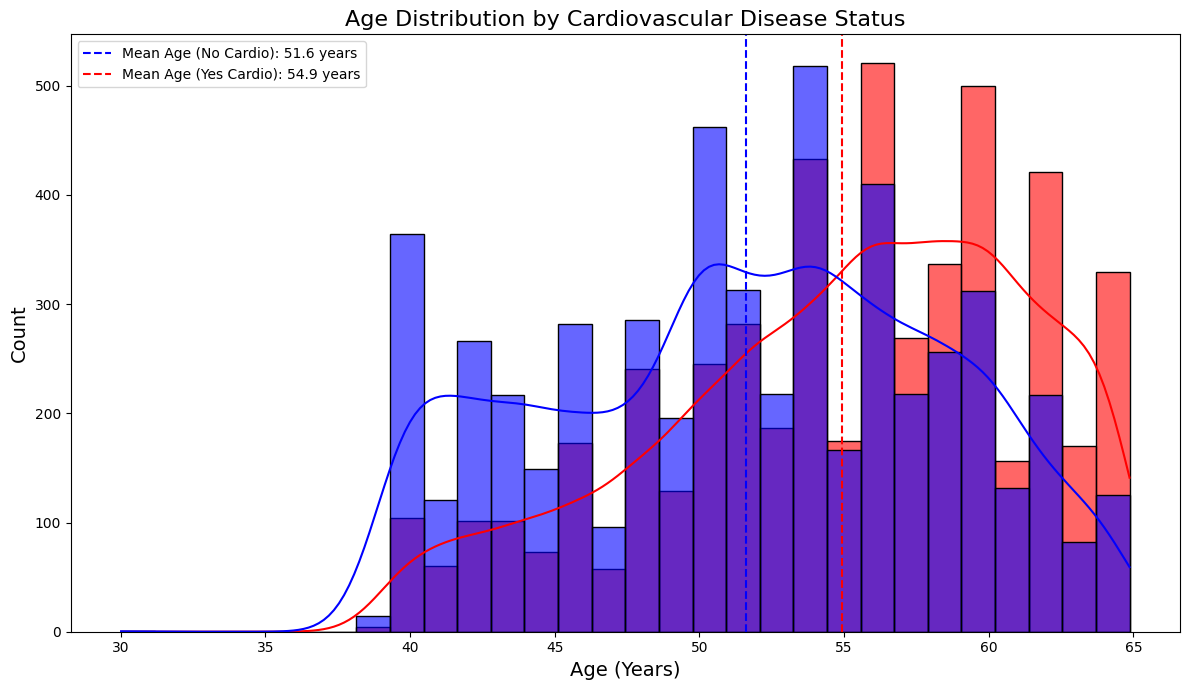

In [81]:
# Convert age from days to years (assuming the age is in days)
df['age_years'] = df['age'] / 365.25

# Convert cardio from Yes/No to 1/0
df['cardio_numeric'] = df['cardio'].map({'Yes': 1, 'No': 0})

# Create a better histogram plot for age distribution comparing cardio=Yes vs cardio=No
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='age_years', hue='cardio', bins=30, 
             palette=['blue', 'red'], alpha=0.6, kde=True,
             hue_order=['No', 'Yes'])

plt.title('Age Distribution by Cardiovascular Disease Status', fontsize=16)
plt.xlabel('Age (Years)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cardiovascular Disease', labels=['No', 'Yes'])

# Add a vertical line for the mean age of each group
mean_age_no_cardio = df[df['cardio'] == 'No']['age_years'].mean()
mean_age_yes_cardio = df[df['cardio'] == 'Yes']['age_years'].mean()

plt.axvline(x=mean_age_no_cardio, color='blue', linestyle='--', 
            label=f'Mean Age (No Cardio): {mean_age_no_cardio:.1f} years')
plt.axvline(x=mean_age_yes_cardio, color='red', linestyle='--',
            label=f'Mean Age (Yes Cardio): {mean_age_yes_cardio:.1f} years')

plt.legend()
plt.tight_layout()
plt.show()

Age and Gluc

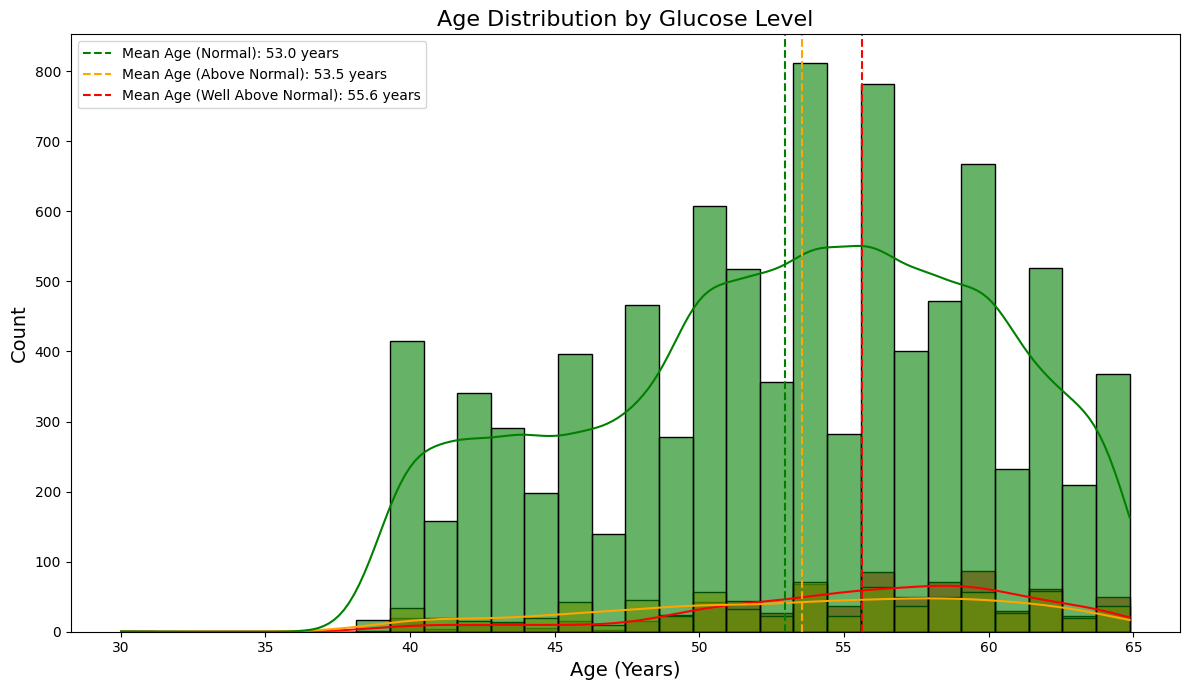

In [82]:
# Create a better histogram plot for age distribution comparing cholesterol levels
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='age_years', hue='gluc', bins=30, 
             palette=['green', 'orange', 'red'], alpha=0.6, kde=True,
             hue_order=['normal', 'above normal', 'well above normal'])

plt.title('Age Distribution by Glucose Level', fontsize=16)
plt.xlabel('Age (Years)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Glucose Level', labels=['Normal', 'Above Normal', 'Well Above Normal'])

# Add a vertical line for the mean age of each group
mean_age_normal_gluc = df[df['gluc'] == 'normal']['age_years'].mean()
mean_age_abovenormal_gluc = df[df['gluc'] == 'above normal']['age_years'].mean()
mean_age_wellabovenormal_gluc = df[df['gluc'] == 'well above normal']['age_years'].mean()

plt.axvline(x=mean_age_normal_gluc, color='green', linestyle='--', 
            label=f'Mean Age (Normal): {mean_age_normal_gluc:.1f} years')
plt.axvline(x=mean_age_abovenormal_gluc, color='orange', linestyle='--',
            label=f'Mean Age (Above Normal): {mean_age_abovenormal_gluc:.1f} years')
plt.axvline(x=mean_age_wellabovenormal_gluc, color='red', linestyle='--',
            label=f'Mean Age (Well Above Normal): {mean_age_wellabovenormal_gluc:.1f} years')

plt.legend()
plt.tight_layout()
plt.show()

Age and Cholesterol

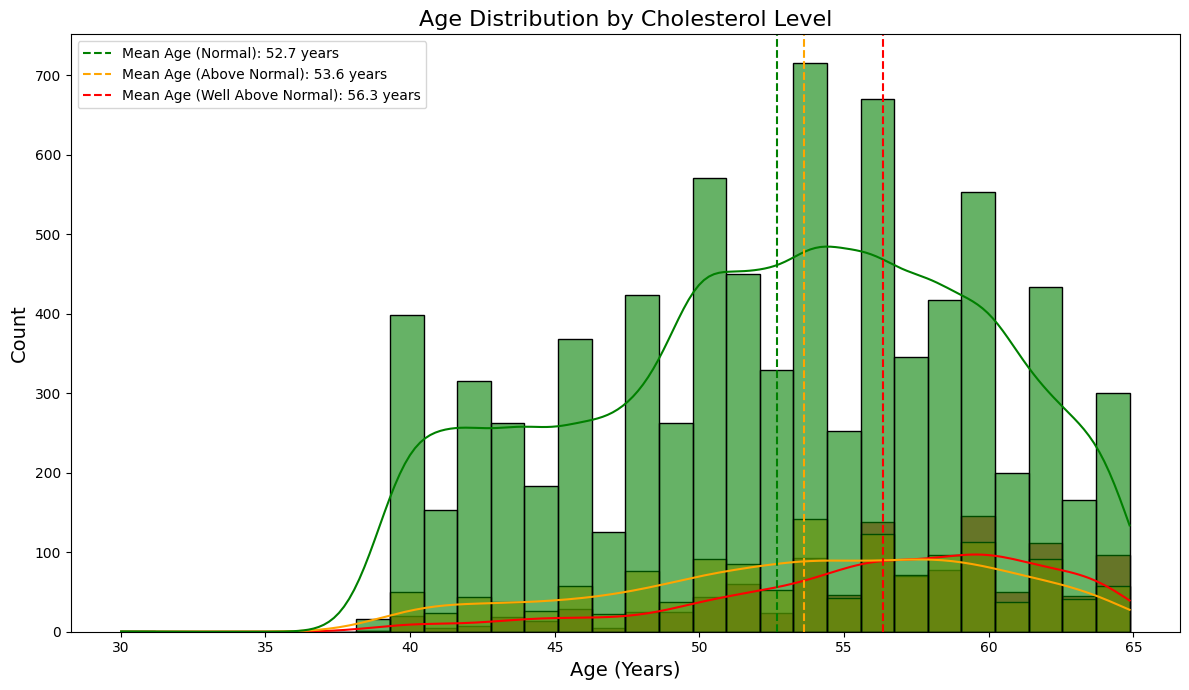

In [83]:
# Create a better histogram plot for age distribution comparing cholesterol levels
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='age_years', hue='cholesterol', bins=30, 
             palette=['green', 'orange', 'red'], alpha=0.6, kde=True,
             hue_order=['normal', 'above normal', 'well above normal'])

plt.title('Age Distribution by Cholesterol Level', fontsize=16)
plt.xlabel('Age (Years)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cholesterol Level', labels=['Normal', 'Above Normal', 'Well Above Normal'])

# Add a vertical line for the mean age of each group
mean_age_normal_cholesterol = df[df['cholesterol'] == 'normal']['age_years'].mean()
mean_age_abovenormal_cholesterol = df[df['cholesterol'] == 'above normal']['age_years'].mean()
mean_age_wellabovenormal_cholesterol = df[df['cholesterol'] == 'well above normal']['age_years'].mean()

plt.axvline(x=mean_age_normal_cholesterol, color='green', linestyle='--', 
            label=f'Mean Age (Normal): {mean_age_normal_cholesterol:.1f} years')
plt.axvline(x=mean_age_abovenormal_cholesterol, color='orange', linestyle='--',
            label=f'Mean Age (Above Normal): {mean_age_abovenormal_cholesterol:.1f} years')
plt.axvline(x=mean_age_wellabovenormal_cholesterol, color='red', linestyle='--',
            label=f'Mean Age (Well Above Normal): {mean_age_wellabovenormal_cholesterol:.1f} years')

plt.legend()
plt.tight_layout()
plt.show()

Age and Ap_lo

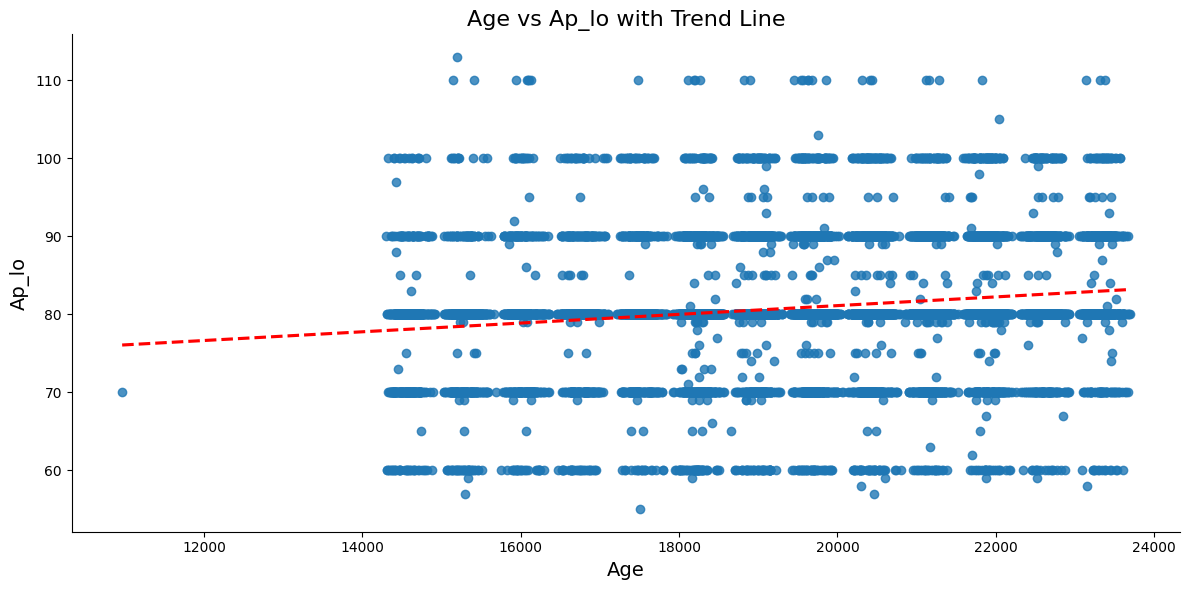

In [ ]:
# Plot the relationship between age and ap_lo
#ตีเส้น trend line
sns.lmplot(data=df, x='age', y='ap_lo', aspect=2, height=6,
           line_kws={'color': 'red', 'linestyle': '--'}, ci=None)
plt.title('Age vs Ap_lo with Trend Line', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Ap_lo', fontsize=14)
plt.tight_layout()
plt.show()

Age and Ap_hi

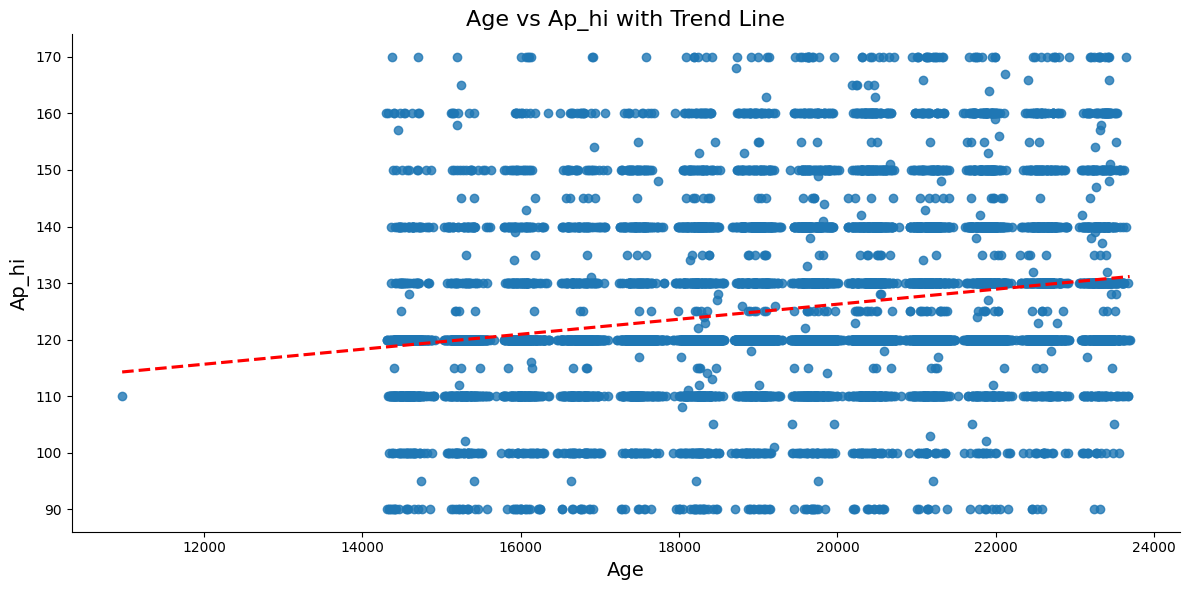

In [85]:
# Plot the relationship between age and ap_lo
#ตีเส้น trend line
sns.lmplot(data=df, x='age', y='ap_hi', aspect=2, height=6,
           line_kws={'color': 'red', 'linestyle': '--'}, ci=None)
plt.title('Age vs Ap_hi with Trend Line', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Ap_hi', fontsize=14)
plt.tight_layout()
plt.show()

Gender-relation correlation


Gender and Alco

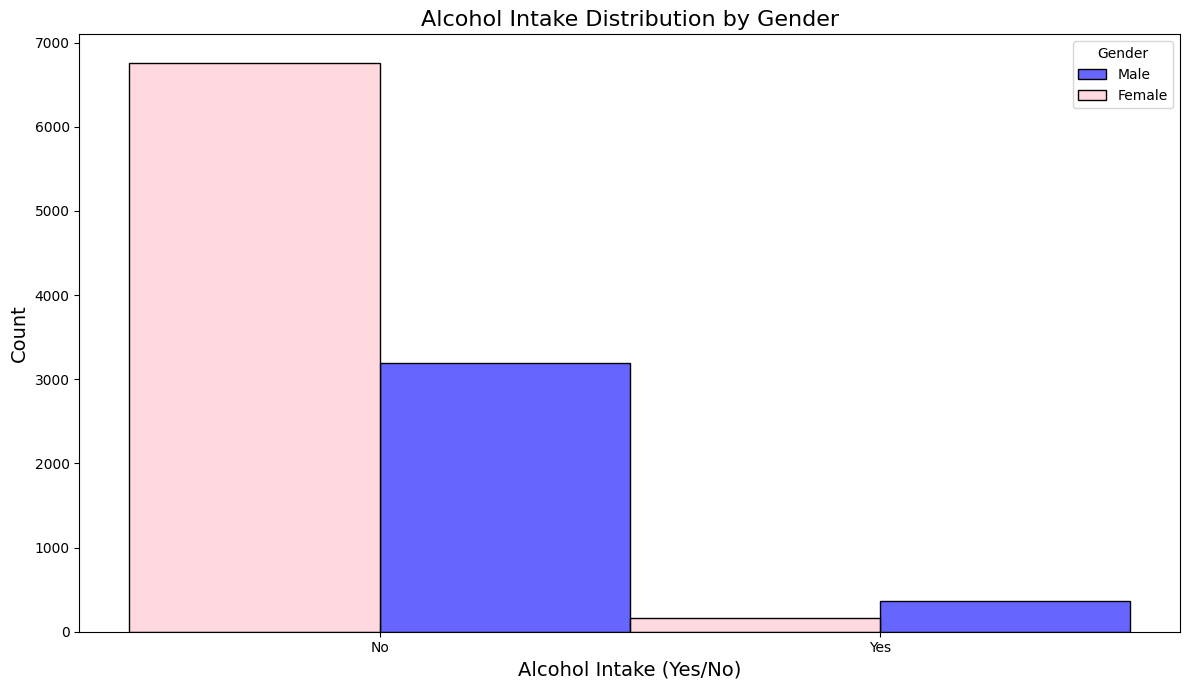

In [86]:
# Create a histogram plot for alcohol intake distribution comparing gender
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='alco', hue='gender', bins=3, 
             palette=['pink', 'blue'], alpha=0.6, multiple='dodge')
plt.title('Alcohol Intake Distribution by Gender', fontsize=16)
plt.xlabel('Alcohol Intake (Yes/No)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Gender', labels=['Male', 'Female'])

plt.tight_layout()
plt.show()

Gender and Smoke

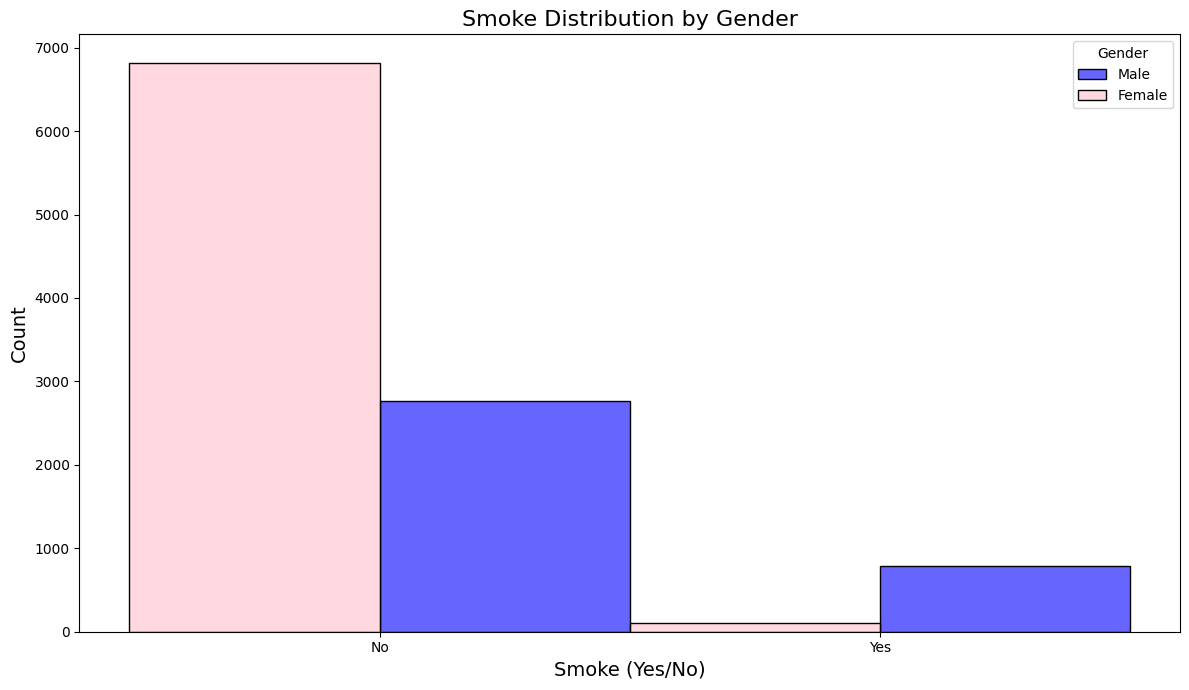

In [87]:
# Create a histogram plot for alcohol intake distribution comparing gender
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='smoke', hue='gender', bins=6, 
             palette=['pink', 'blue'], alpha=0.6, multiple='dodge')
plt.title('Smoke Distribution by Gender', fontsize=16)
plt.xlabel('Smoke (Yes/No)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Gender', labels=['Male', 'Female'])

plt.tight_layout()
plt.show()

Gender and Weight

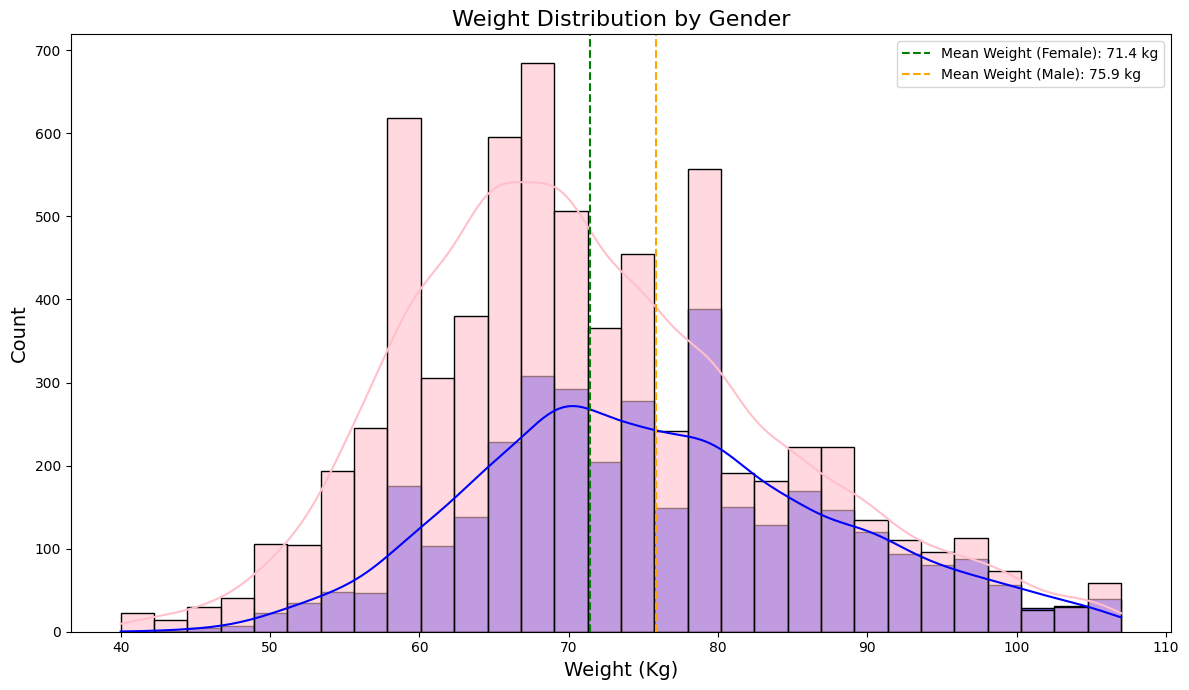

In [88]:
# Create a better histogram plot for weight distribution comparing gender
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='weight', hue='gender', bins=30, 
             palette=['pink', 'blue'], alpha=0.6, kde=True,
             hue_order=['Female', 'Male'])

plt.title('Weight Distribution by Gender', fontsize=16)
plt.xlabel('Weight (Kg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Gender', labels=['Female', 'Male'])

# Add a vertical line for the mean weight of each group
mean_weight_female = df[df['gender'] == 'Female']['weight'].mean()
mean_weight_male = df[df['gender'] == 'Male']['weight'].mean()

plt.axvline(x=mean_weight_female, color='green', linestyle='--', 
            label=f'Mean Weight (Female): {mean_weight_female:.1f} kg')
plt.axvline(x=mean_weight_male, color='orange', linestyle='--',
            label=f'Mean Weight (Male): {mean_weight_male:.1f} kg')

plt.legend()
plt.tight_layout()
plt.show()


Gender and Height

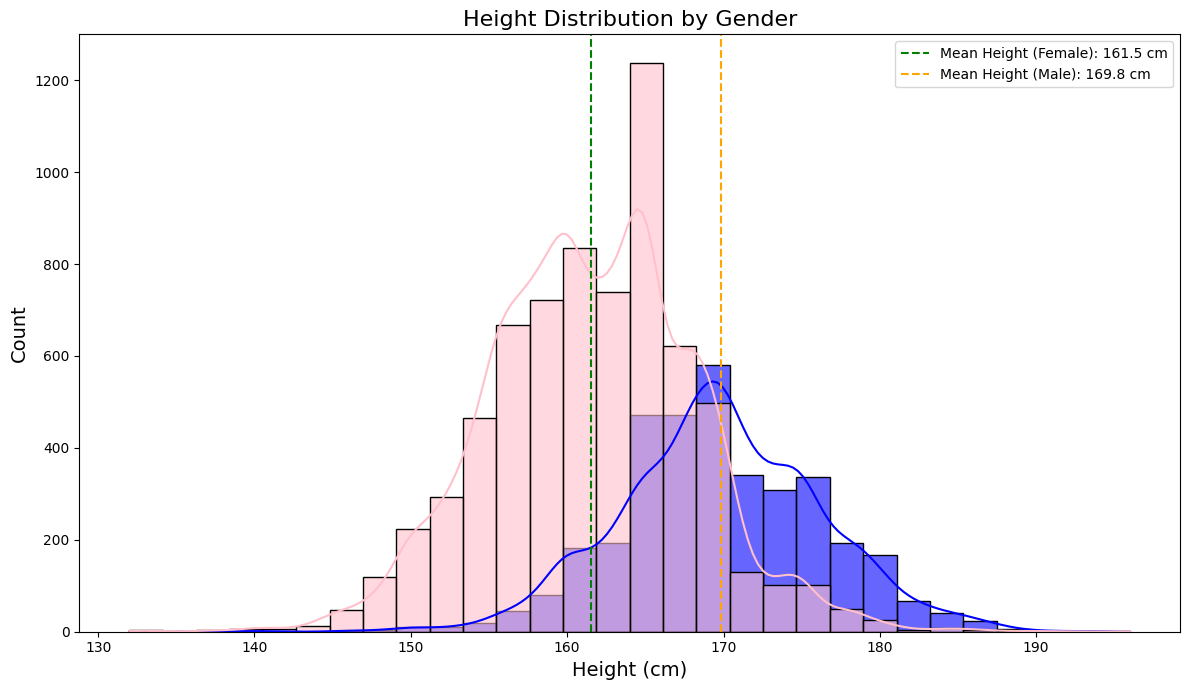

In [91]:
# Create a better histogram plot for height distribution comparing gender
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='height', hue='gender', bins=30, 
             palette=['pink', 'blue'], alpha=0.6, kde=True,
             hue_order=['Female', 'Male'])

plt.title('Height Distribution by Gender', fontsize=16)
plt.xlabel('Height (cm)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Gender', labels=['Female', 'Male'])

# Add a vertical line for the mean height of each group
mean_height_female = df[df['gender'] == 'Female']['height'].mean()
mean_height_male = df[df['gender'] == 'Male']['height'].mean()

plt.axvline(x=mean_height_female, color='green', linestyle='--', 
            label=f'Mean Height (Female): {mean_height_female:.1f} cm')
plt.axvline(x=mean_height_male, color='orange', linestyle='--',
            label=f'Mean Height (Male): {mean_height_male:.1f} cm')

plt.legend()
plt.tight_layout()
plt.show()


Height-relation correlation


Height and Smoke


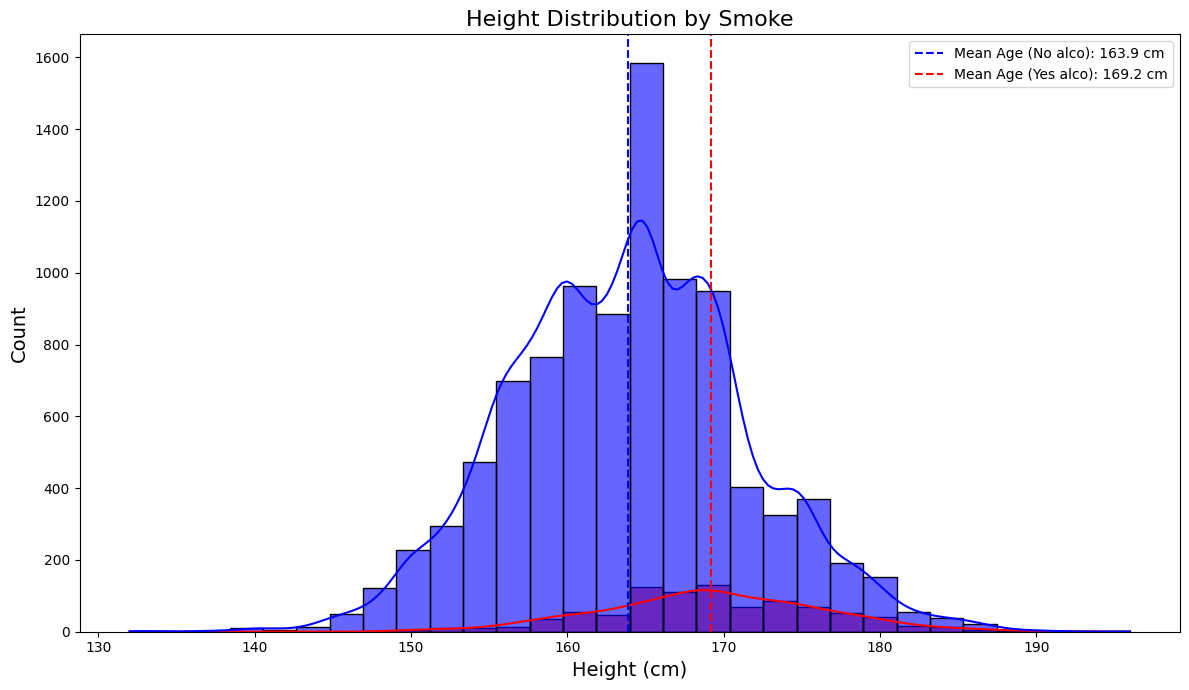

In [95]:
# Create a better histogram plot for age distribution comparing cardio=Yes vs cardio=No
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='height', hue='smoke', bins=30, 
             palette=['blue', 'red'], alpha=0.6, kde=True,
             hue_order=['No', 'Yes'])

plt.title('Height Distribution by Smoke', fontsize=16)
plt.xlabel('Height (cm)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Smoke', labels=['No', 'Yes'])

# Add a vertical line for the mean age of each group
mean_height_no_snoke = df[df['smoke'] == 'No']['height'].mean()
mean_height_yes_smoke = df[df['smoke'] == 'Yes']['height'].mean()

plt.axvline(x=mean_height_no_snoke, color='blue', linestyle='--', 
            label=f'Mean Age (No alco): {mean_height_no_snoke:.1f} cm')
plt.axvline(x=mean_height_yes_smoke, color='red', linestyle='--',
            label=f'Mean Age (Yes alco): {mean_height_yes_smoke:.1f} cm')

plt.legend()
plt.tight_layout()
plt.show()

Height and Weight

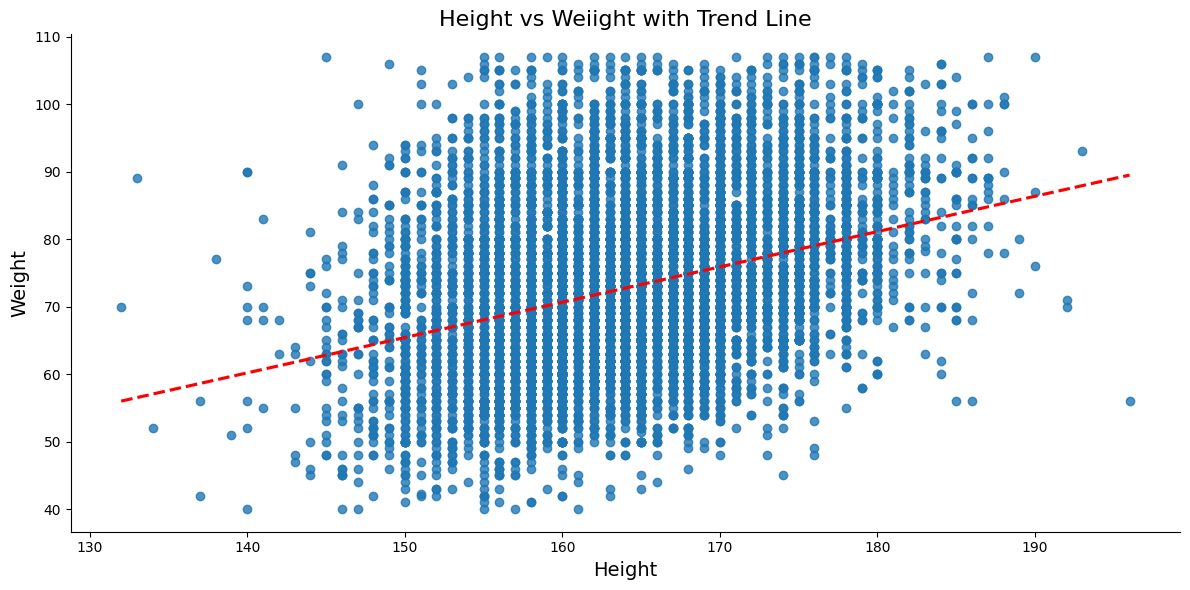

In [97]:
# Plot the relationship between age and ap_lo
#ตีเส้น trend line
sns.lmplot(data=df, x='height', y='weight', aspect=2, height=6,
           line_kws={'color': 'red', 'linestyle': '--'}, ci=None)
plt.title('Height vs Weiight with Trend Line', fontsize=16)
plt.xlabel('Height', fontsize=14)
plt.ylabel('Weight', fontsize=14)
plt.tight_layout()
plt.show()

Weight-relation correlation

Weight and Cardio

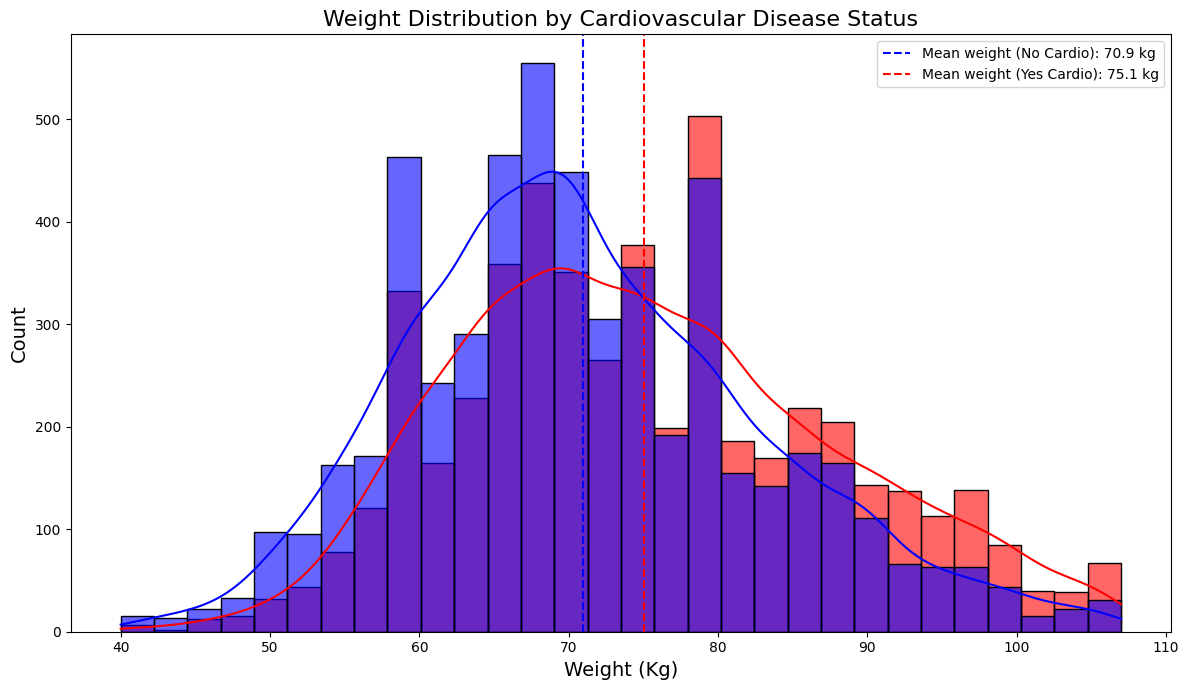

In [98]:
# Create a better histogram plot for age distribution comparing cardio=Yes vs cardio=No
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='weight', hue='cardio', bins=30, 
             palette=['blue', 'red'], alpha=0.6, kde=True,
             hue_order=['No', 'Yes'])

plt.title('Weight Distribution by Cardiovascular Disease Status', fontsize=16)
plt.xlabel('Weight (Kg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cardiovascular Disease', labels=['No', 'Yes'])

# Add a vertical line for the mean age of each group
mean_age_no_cardio = df[df['cardio'] == 'No']['weight'].mean()
mean_age_yes_cardio = df[df['cardio'] == 'Yes']['weight'].mean()

plt.axvline(x=mean_age_no_cardio, color='blue', linestyle='--', 
            label=f'Mean weight (No Cardio): {mean_age_no_cardio:.1f} kg')
plt.axvline(x=mean_age_yes_cardio, color='red', linestyle='--',
            label=f'Mean weight (Yes Cardio): {mean_age_yes_cardio:.1f} kg')

plt.legend()
plt.tight_layout()
plt.show()

Weight and Cholesterol

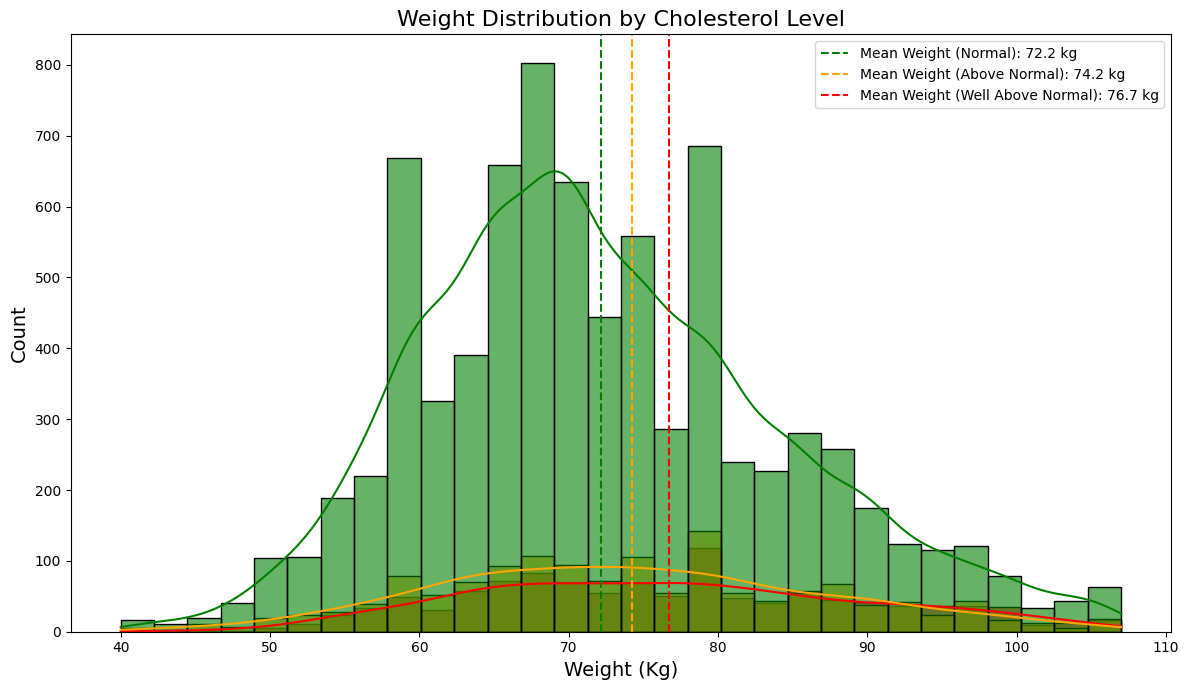

In [100]:
# Create a better histogram plot for weight distribution comparing glucose levels
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='weight', hue='cholesterol', bins=30, 
             palette=['green', 'orange', 'red'], alpha=0.6, kde=True,
             hue_order=['normal', 'above normal', 'well above normal'])

plt.title('Weight Distribution by Cholesterol Level', fontsize=16)
plt.xlabel('Weight (Kg)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Glucose Level', labels=['Normal', 'Above Normal', 'Well Above Normal'])

# Add a vertical line for the mean weight of each group
mean_weight_normal_gluc = df[df['cholesterol'] == 'normal']['weight'].mean()
mean_weight_abovenormal_gluc = df[df['cholesterol'] == 'above normal']['weight'].mean()
mean_weight_wellabovenormal_gluc = df[df['cholesterol'] == 'well above normal']['weight'].mean()

plt.axvline(x=mean_weight_normal_gluc, color='green', linestyle='--', 
            label=f'Mean Weight (Normal): {mean_weight_normal_gluc:.1f} kg')
plt.axvline(x=mean_weight_abovenormal_gluc, color='orange', linestyle='--',
            label=f'Mean Weight (Above Normal): {mean_weight_abovenormal_gluc:.1f} kg')
plt.axvline(x=mean_weight_wellabovenormal_gluc, color='red', linestyle='--',
            label=f'Mean Weight (Well Above Normal): {mean_weight_wellabovenormal_gluc:.1f} kg')

plt.legend()
plt.tight_layout()
plt.show()

Weight and Ap_lo

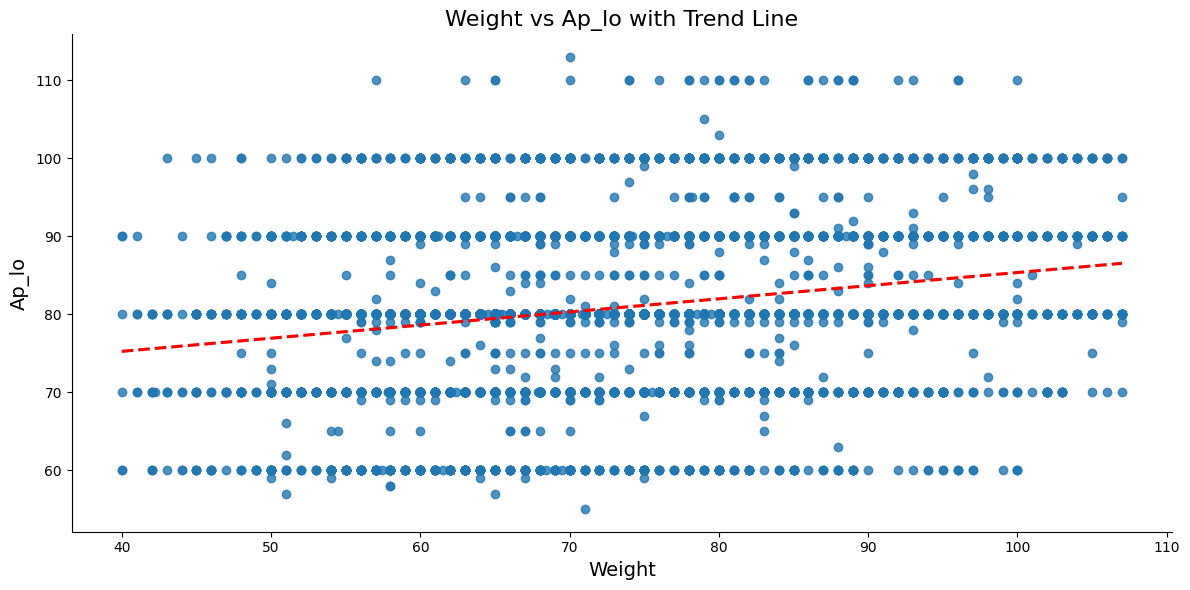

In [101]:
# Plot the relationship between age and ap_lo
#ตีเส้น trend line
sns.lmplot(data=df, x='weight', y='ap_lo', aspect=2, height=6,
           line_kws={'color': 'red', 'linestyle': '--'}, ci=None)
plt.title('Weight vs Ap_lo with Trend Line', fontsize=16)
plt.xlabel('Weight', fontsize=14)
plt.ylabel('Ap_lo', fontsize=14)
plt.tight_layout()
plt.show()

Weight and Ap_hi

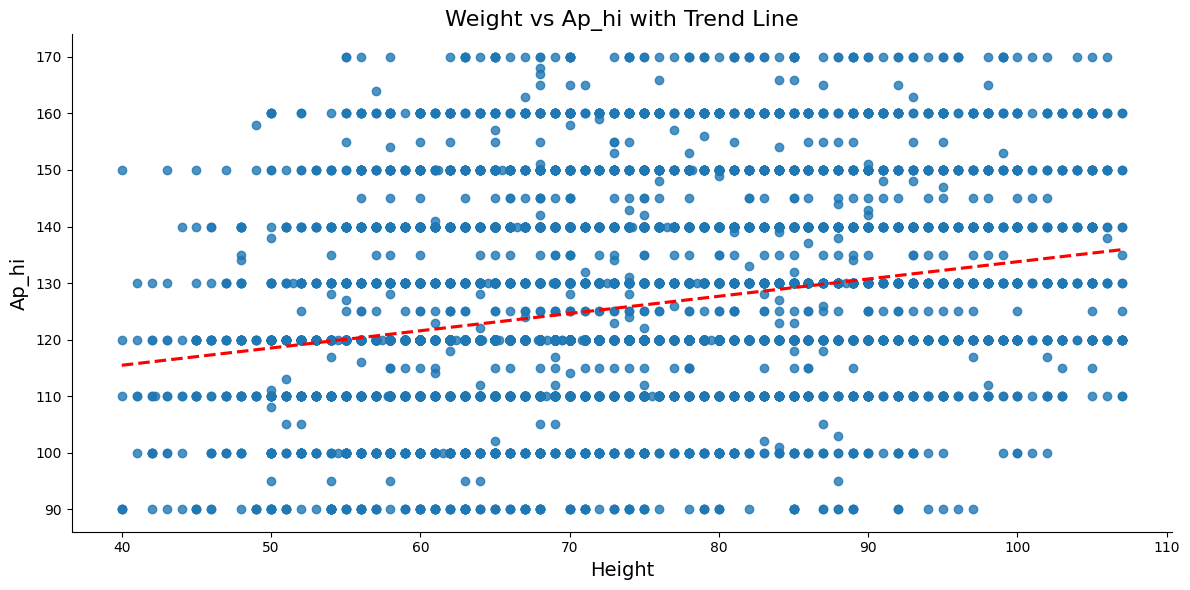

In [102]:
# Plot the relationship between age and ap_lo
#ตีเส้น trend line
sns.lmplot(data=df, x='weight', y='ap_hi', aspect=2, height=6,
           line_kws={'color': 'red', 'linestyle': '--'}, ci=None)
plt.title('Weight vs Ap_hi with Trend Line', fontsize=16)
plt.xlabel('Height', fontsize=14)
plt.ylabel('Ap_hi', fontsize=14)
plt.tight_layout()
plt.show()

Ap_hi-relation correlation


Ap_hi and Cardio

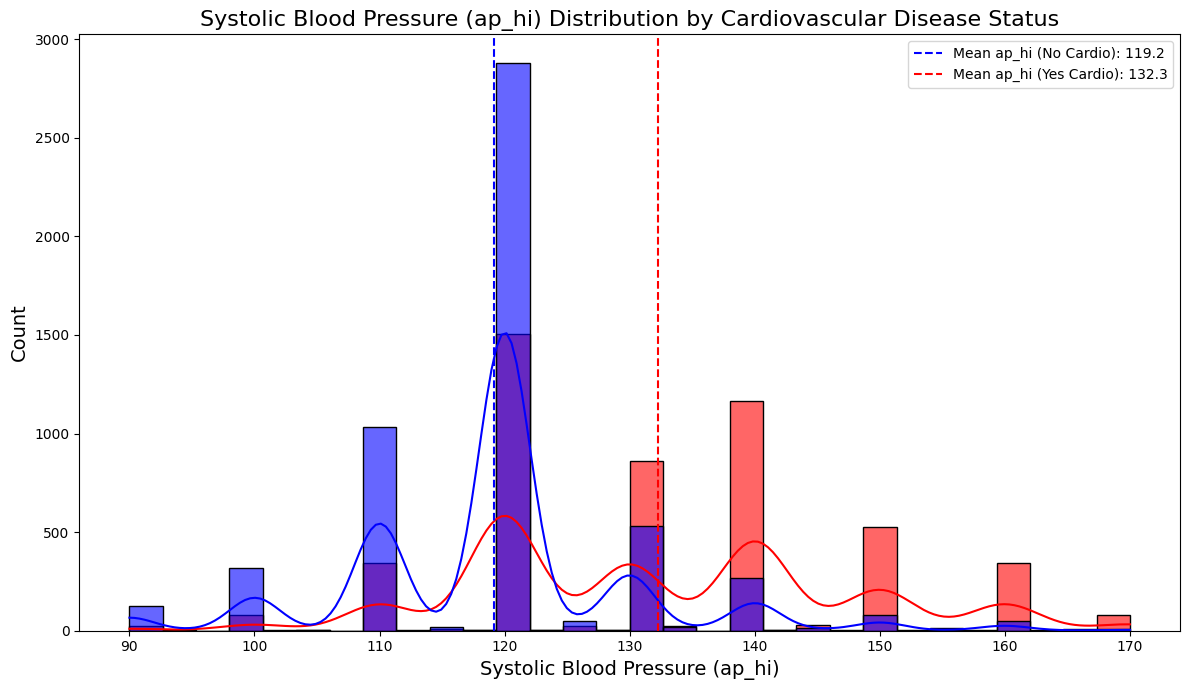

In [103]:
# Create a better histogram plot for age distribution comparing cardio=Yes vs cardio=No
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='ap_hi', hue='cardio', bins=30, 
             palette=['blue', 'red'], alpha=0.6, kde=True,
             hue_order=['No', 'Yes'])

plt.title('Systolic Blood Pressure (ap_hi) Distribution by Cardiovascular Disease Status', fontsize=16)
plt.xlabel('Systolic Blood Pressure (ap_hi)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cardiovascular Disease', labels=['No', 'Yes'])

# Add a vertical line for the mean ap_hi of each group
mean_ap_hi_no_cardio = df[df['cardio'] == 'No']['ap_hi'].mean()
mean_ap_hi_yes_cardio = df[df['cardio'] == 'Yes']['ap_hi'].mean()

plt.axvline(x=mean_ap_hi_no_cardio, color='blue', linestyle='--', 
            label=f'Mean ap_hi (No Cardio): {mean_ap_hi_no_cardio:.1f}')
plt.axvline(x=mean_ap_hi_yes_cardio, color='red', linestyle='--',
            label=f'Mean ap_hi (Yes Cardio): {mean_ap_hi_yes_cardio:.1f}')

plt.legend()
plt.tight_layout()
plt.show()

Ap_hi and Cholesterol

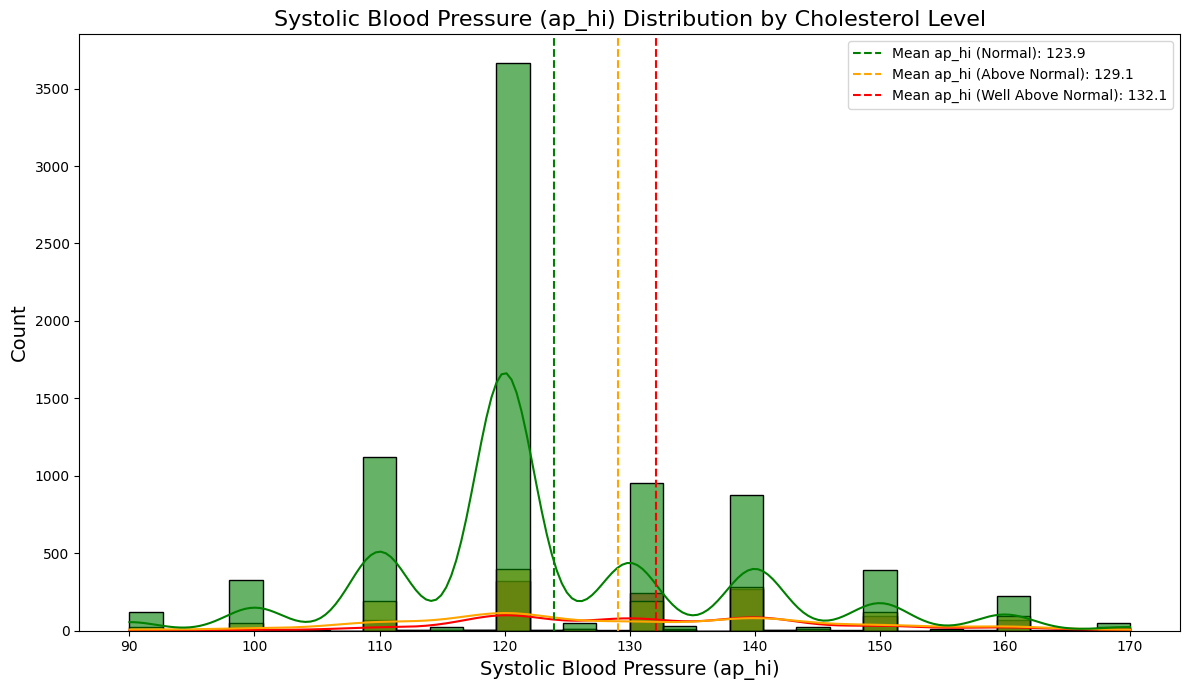

In [105]:
# Create a better histogram plot for ap_hi distribution comparing cholesterol levels
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='ap_hi', hue='cholesterol', bins=30, 
             palette=['green', 'orange', 'red'], alpha=0.6, kde=True,
             hue_order=['normal', 'above normal', 'well above normal'])

plt.title('Systolic Blood Pressure (ap_hi) Distribution by Cholesterol Level', fontsize=16)
plt.xlabel('Systolic Blood Pressure (ap_hi)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cholesterol Level', labels=['Normal', 'Above Normal', 'Well Above Normal'])

# Add a vertical line for the mean ap_hi of each group
mean_ap_hi_normal_cholesterol = df[df['cholesterol'] == 'normal']['ap_hi'].mean()
mean_ap_hi_abovenormal_cholesterol = df[df['cholesterol'] == 'above normal']['ap_hi'].mean()
mean_ap_hi_wellabovenormal_cholesterol = df[df['cholesterol'] == 'well above normal']['ap_hi'].mean()

plt.axvline(x=mean_ap_hi_normal_cholesterol, color='green', linestyle='--', 
            label=f'Mean ap_hi (Normal): {mean_ap_hi_normal_cholesterol:.1f}')
plt.axvline(x=mean_ap_hi_abovenormal_cholesterol, color='orange', linestyle='--',
            label=f'Mean ap_hi (Above Normal): {mean_ap_hi_abovenormal_cholesterol:.1f}')
plt.axvline(x=mean_ap_hi_wellabovenormal_cholesterol, color='red', linestyle='--',
            label=f'Mean ap_hi (Well Above Normal): {mean_ap_hi_wellabovenormal_cholesterol:.1f}')

plt.legend()
plt.tight_layout()
plt.show()


Ap_hi and Ap_lo

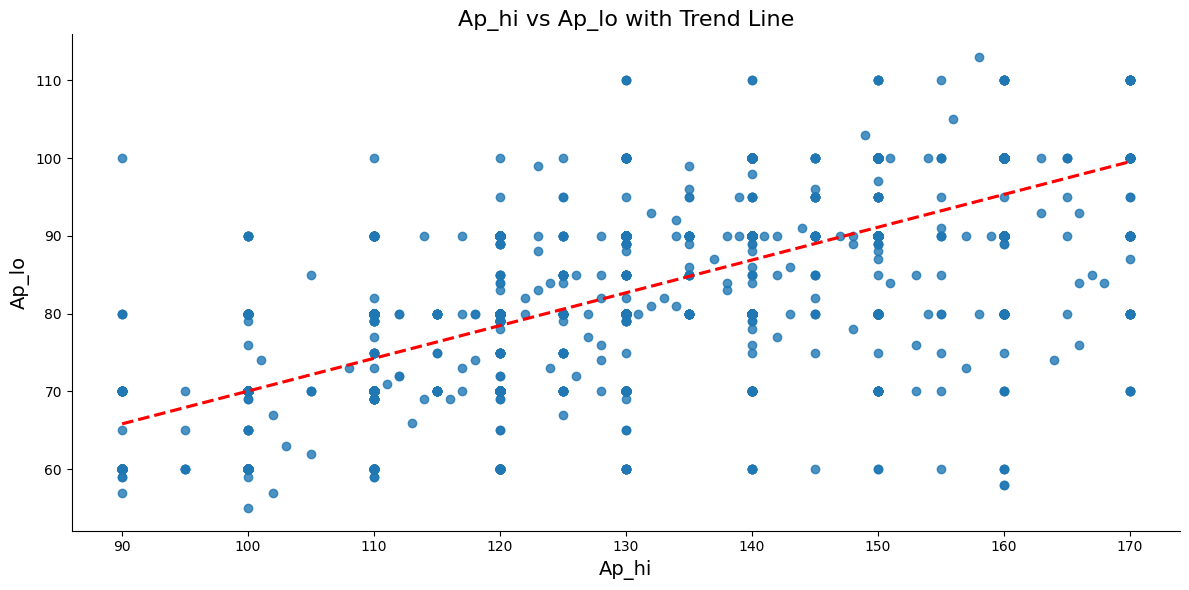

In [106]:
# Plot the relationship between age and ap_lo
#ตีเส้น trend line
sns.lmplot(data=df, x='ap_hi', y='ap_lo', aspect=2, height=6,
           line_kws={'color': 'red', 'linestyle': '--'}, ci=None)
plt.title('Ap_hi vs Ap_lo with Trend Line', fontsize=16)
plt.xlabel('Ap_hi', fontsize=14)
plt.ylabel('Ap_lo', fontsize=14)
plt.tight_layout()
plt.show()

Ap_lo-realation correlation

Ap_lo and Cardio

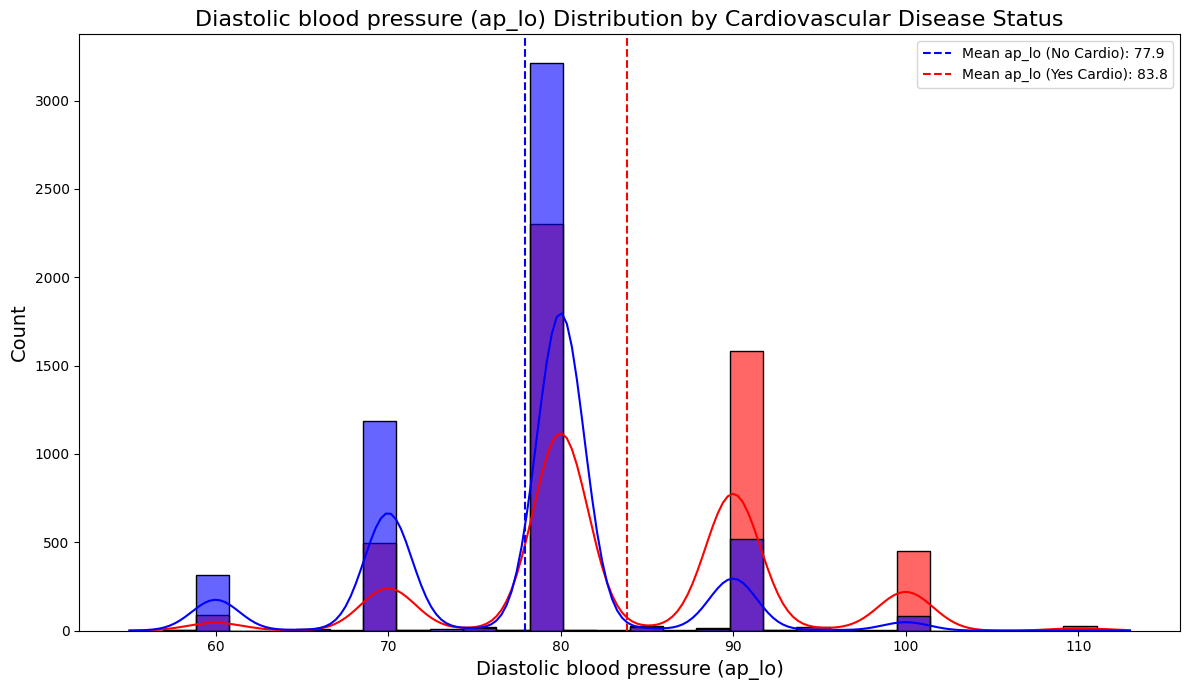

In [107]:
# Create a better histogram plot for age distribution comparing cardio=Yes vs cardio=No
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='ap_lo', hue='cardio', bins=30, 
             palette=['blue', 'red'], alpha=0.6, kde=True,
             hue_order=['No', 'Yes'])

plt.title('Diastolic blood pressure (ap_lo) Distribution by Cardiovascular Disease Status', fontsize=16)
plt.xlabel('Diastolic blood pressure (ap_lo)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cardiovascular Disease', labels=['No', 'Yes'])

# Add a vertical line for the mean ap_lo of each group
mean_ap_lo_no_cardio = df[df['cardio'] == 'No']['ap_lo'].mean()
mean_ap_lo_yes_cardio = df[df['cardio'] == 'Yes']['ap_lo'].mean()

plt.axvline(x=mean_ap_lo_no_cardio, color='blue', linestyle='--', 
            label=f'Mean ap_lo (No Cardio): {mean_ap_lo_no_cardio:.1f}')
plt.axvline(x=mean_ap_lo_yes_cardio, color='red', linestyle='--',
            label=f'Mean ap_lo (Yes Cardio): {mean_ap_lo_yes_cardio:.1f}')

plt.legend()
plt.tight_layout()
plt.show()

Ap_lo and Cholesterol

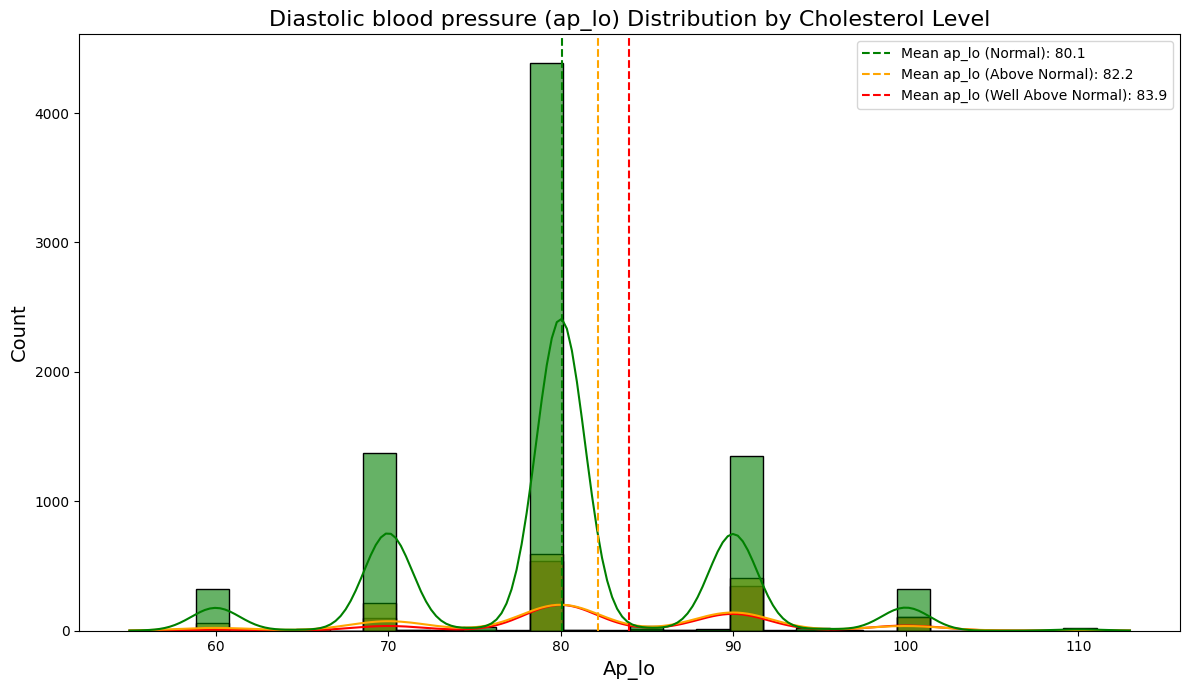

In [108]:
# Create a better histogram plot for age distribution comparing cholesterol levels
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='ap_lo', hue='cholesterol', bins=30, 
             palette=['green', 'orange', 'red'], alpha=0.6, kde=True,
             hue_order=['normal', 'above normal', 'well above normal'])

plt.title('Diastolic blood pressure (ap_lo) Distribution by Cholesterol Level', fontsize=16)
plt.xlabel('Ap_lo', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cholesterol Level', labels=['Normal', 'Above Normal', 'Well Above Normal'])

# Add a vertical line for the mean age of each group
mean_ap_lo_normal_cholesterol = df[df['cholesterol'] == 'normal']['ap_lo'].mean()
mean_ap_lo_abovenormal_cholesterol = df[df['cholesterol'] == 'above normal']['ap_lo'].mean()
mean_ap_lo_wellabovenormal_cholesterol = df[df['cholesterol'] == 'well above normal']['ap_lo'].mean()

plt.axvline(x=mean_ap_lo_normal_cholesterol, color='green', linestyle='--', 
            label=f'Mean ap_lo (Normal): {mean_ap_lo_normal_cholesterol:.1f}')
plt.axvline(x=mean_ap_lo_abovenormal_cholesterol, color='orange', linestyle='--',
            label=f'Mean ap_lo (Above Normal): {mean_ap_lo_abovenormal_cholesterol:.1f}')
plt.axvline(x=mean_ap_lo_wellabovenormal_cholesterol, color='red', linestyle='--',
            label=f'Mean ap_lo (Well Above Normal): {mean_ap_lo_wellabovenormal_cholesterol:.1f}')

plt.legend()
plt.tight_layout()
plt.show()

Cholesterol-relation correlation

Cholesterol and Cardio

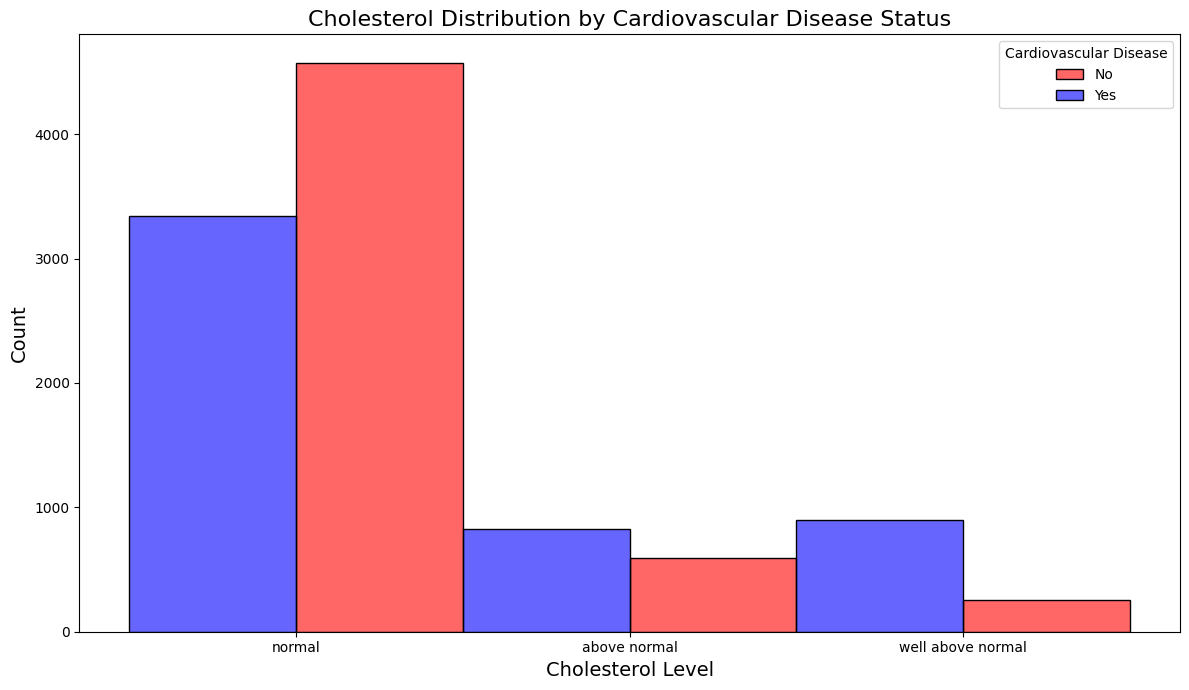

In [111]:
# Create a better histogram plot for cholesterol distribution comparing cardio levels
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='cholesterol', hue='cardio', bins=10, 
             palette=['blue', 'red'], alpha=0.6, multiple='dodge',
             hue_order=['Yes', 'No'])

plt.title('Cholesterol Distribution by Cardiovascular Disease Status', fontsize=16)
plt.xlabel('Cholesterol Level', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cardiovascular Disease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()


Cholesterol and Gluc

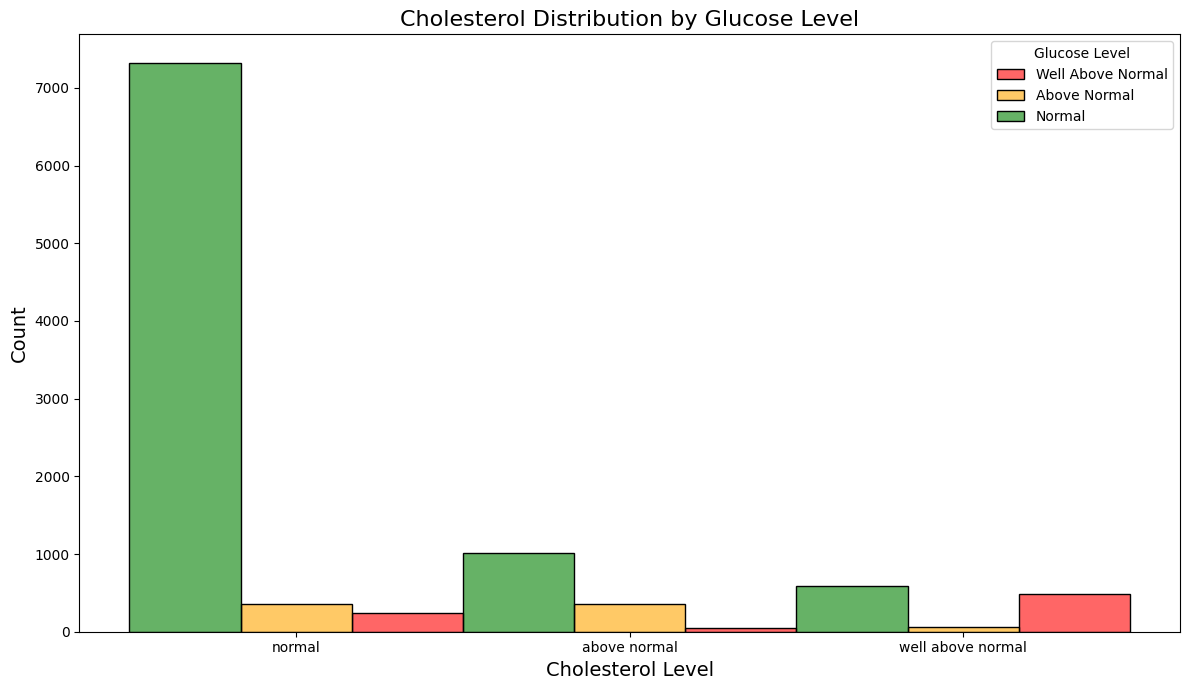

In [113]:
# Create a better histogram plot for cholesterol distribution comparing glucose levels
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='cholesterol', hue='gluc', bins=20, 
             palette=['green', 'orange', 'red'], alpha=0.6, multiple='dodge',
             hue_order=['normal', 'above normal', 'well above normal'])

plt.title('Cholesterol Distribution by Glucose Level', fontsize=16)
plt.xlabel('Cholesterol Level', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Glucose Level', labels=['Well Above Normal', 'Above Normal', 'Normal'])

plt.tight_layout()
plt.show()

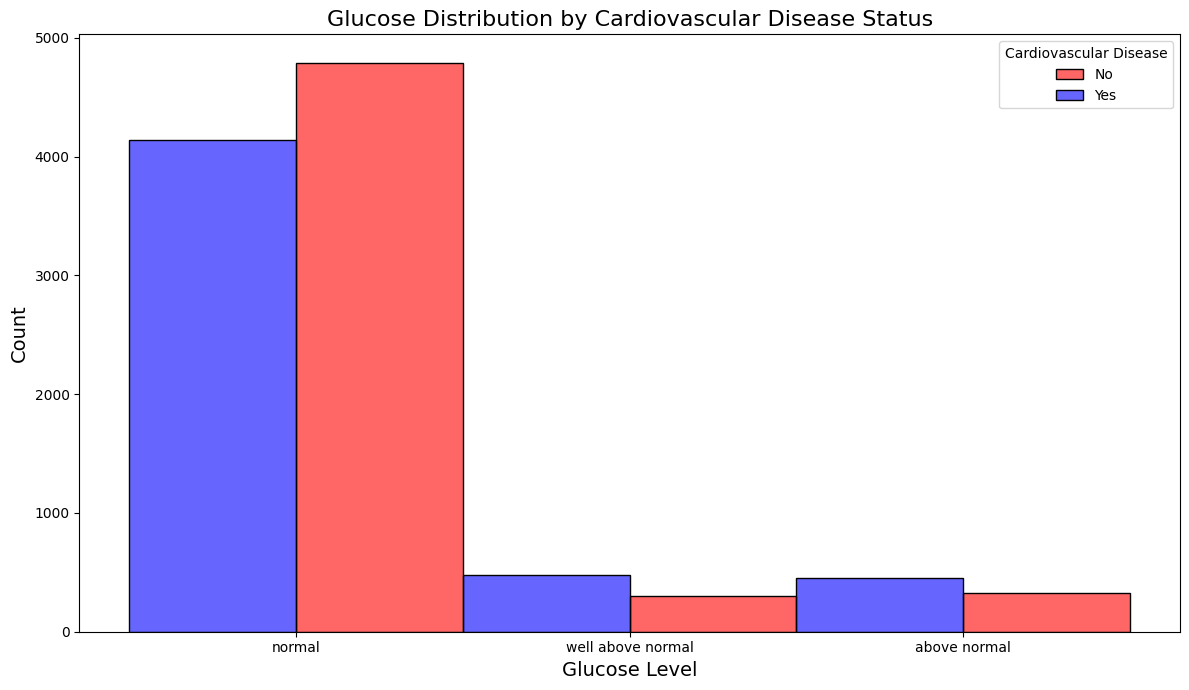

In [117]:
# Create a better histogram plot for cholesterol distribution comparing cardio levels
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='gluc', hue='cardio', bins=5, 
             palette=['blue', 'red'], alpha=0.6, multiple='dodge',
             hue_order=['Yes', 'No'])

plt.title('Glucose Distribution by Cardiovascular Disease Status', fontsize=16)
plt.xlabel('Glucose Level', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Cardiovascular Disease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

Smoke and Alco

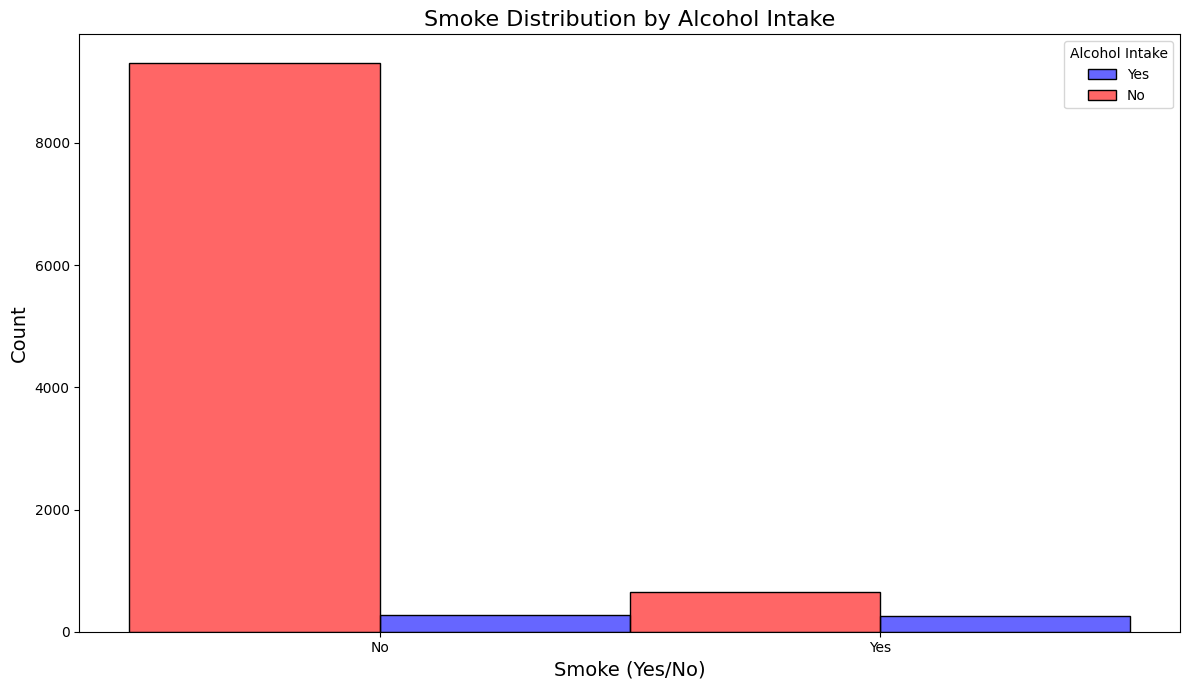

In [118]:
# Create a histogram plot for alcohol intake distribution comparing gender
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='smoke', hue='alco', bins=3, 
             palette=['Red', 'Blue'], alpha=0.6, multiple='dodge')
plt.title('Smoke Distribution by Alcohol Intake', fontsize=16)
plt.xlabel('Smoke (Yes/No)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(title='Alcohol Intake', labels=['Yes', 'No'])

plt.tight_layout()
plt.show()

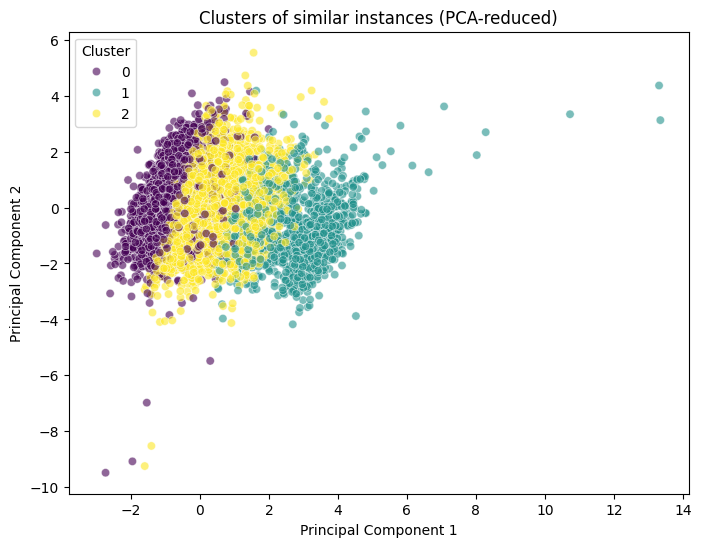

KMeans clustering completed. Use silhouette score and other evaluations to refine the clustering.


In [59]:
import pandas as pd  
from sklearn.preprocessing import StandardScaler, LabelEncoder  
from sklearn.decomposition import PCA  
from sklearn.cluster import KMeans  
import matplotlib.pyplot as plt  
import seaborn as sns  
  
# Load the dataset  
df = pd.read_csv('32130_AT2_25745973.csv', encoding='ascii')  
  
# Preprocess data  
# Encode categorical variables  
le = LabelEncoder()  
for col in ['gender', 'smoke', 'alco', 'cardio']:  
    if col in df.columns:  
        df[col] = le.fit_transform(df[col].astype(str))  
  
# Select features (example: age, height, weight, systolic and diastolic bp, cholesterol, gluc)  
features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc']  
data = df[features].dropna()  
  
# Normalize data  
scaler = StandardScaler()  
data_scaled = scaler.fit_transform(data)  
  
# Optional: reduce to 2 principal components for visualization  
pca = PCA(n_components=2)  
data_pca = pca.fit_transform(data_scaled)  
  
# Fit KMeans clustering with a chosen number of clusters k (say, k=3)  
k = 3  
kmeans = KMeans(n_clusters=k, random_state=42)  
clusters = kmeans.fit_predict(data_scaled)  
  
# Visualize the clusters in the PCA-reduced space  
plt.figure(figsize=(8,6))  
sns.scatterplot(x=data_pca[:,0], y=data_pca[:,1], hue=clusters, palette='viridis', alpha=0.6)  
plt.title('Clusters of similar instances (PCA-reduced)')  
plt.xlabel('Principal Component 1')  
plt.ylabel('Principal Component 2')  
plt.legend(title='Cluster')  
plt.show()  
  
print('KMeans clustering completed. Use silhouette score and other evaluations to refine the clustering.') 

In [127]:
file_path = './For Visualize/visualz.csv'
df = pd.read_csv(file_path, encoding='ascii')
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,16905,1,171,60.0,120,70,1,1,0,0,0,0
1,17571,2,175,69.0,130,80,1,1,0,0,0,0
2,18326,1,155,80.0,120,80,1,1,0,0,0,0
3,15310,2,163,71.0,110,70,1,1,0,0,1,0
4,22607,1,165,66.0,120,80,1,1,0,0,0,0


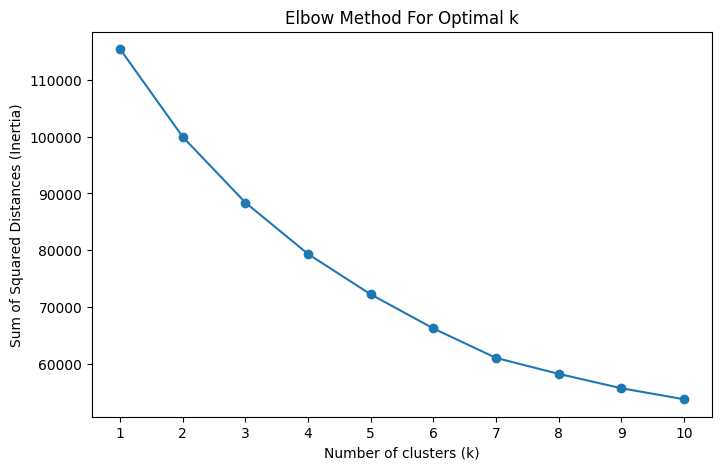

Cluster counts:
cluster
0    6143
2    3340
1    1005
Name: count, dtype: int64


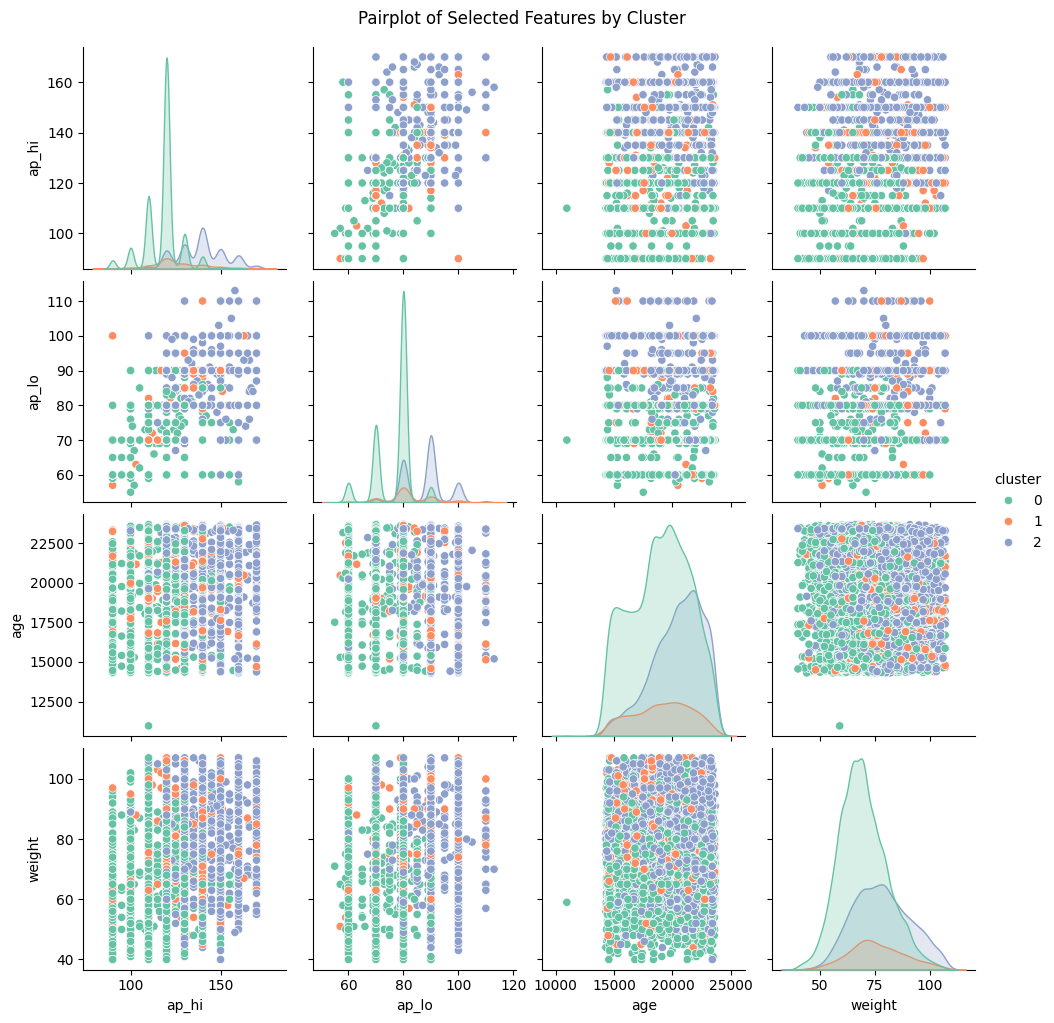

Clustering analysis complete.


In [ ]:
# Clustering Analysis: Identify clusters of similar instances
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features for clustering: adjusted column name from 'chelesterol' to 'cholesterol'
features = ['age', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'gender', 'height', 'smoke', 'alco', 'active']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Determine optimal number of clusters using the Elbow Method
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=110)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.xticks(range(1, 11))
plt.show()

# Based on the elbow plot, we choose k=3 for this analysis
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels

# Display count of instances per cluster
print('Cluster counts:')
print(df['cluster'].value_counts())

# Visualize clusters using pairplot for a subset of features
subset_features = ['ap_hi', 'ap_lo', 'age', 'weight']
pairplot = sns.pairplot(df[subset_features + ['cluster']], hue='cluster', palette='Set2', diag_kind='kde')
pairplot.fig.suptitle('Pairplot of Selected Features by Cluster', y=1.02)

# # Add cluster counts to the legend
# for cluster in df['cluster'].unique():
#     count = df[df['cluster'] == cluster].shape[0]
#     pairplot._legend.texts[cluster].set_text(f"Cluster {cluster} ({count})")

plt.show()

print('Clustering analysis complete.')

In [144]:
from tabulate import tabulate

# แปลง DataFrame เป็นตารางที่สวยงาม
table = tabulate(cluster_stats, headers='keys', tablefmt='pretty', showindex=False)
print(table)


+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------------+--------------------+-----------------------+----------------------+---------------------+---------------------+
| ('cluster', '') |  ('age', 'mean')   | ('gender', 'mean') | ('height', 'mean') | ('weight', 'mean') | ('ap_hi', 'mean')  | ('ap_lo', 'mean') | ('cholesterol', 'mean') |  ('gluc', 'mean')  |   ('smoke', 'mean')   |   ('alco', 'mean')   | ('active', 'mean')  | ('cardio', 'mean')  |
+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------------+--------------------+-----------------------+----------------------+---------------------+---------------------+
|       0.0       | 18962.332248087252 | 1.2773888979326062 | 163.95295458245158 | 69.59326062184601  | 117.97248901188344 | 76.83346898909328 |   1.10

Mean values for each feature by cluster:
                  age     weight       ap_hi      ap_lo  cholesterol  \
cluster                                                                
0        18962.332248  69.593261  117.972489  76.833469     1.101579   
1        19117.083582  75.963582  126.518408  81.448756     1.362189   
2        20404.752395  78.156228  139.053593  87.858683     1.817964   

             gluc    gender      height     smoke      alco    active  
cluster                                                                
0        1.066580  1.277389  163.952955  0.000000  0.012535  0.202507  
1        1.202985  1.898507  169.458706  0.884577  0.371144  0.149254  
2        1.516766  1.285629  163.524551  0.002994  0.025749  0.203892  
Standard deviations for each feature by cluster:
                 age     weight      ap_hi     ap_lo  cholesterol      gluc  \
cluster                                                                       
0        2476.251619  10.937770

<Figure size 1400x800 with 0 Axes>

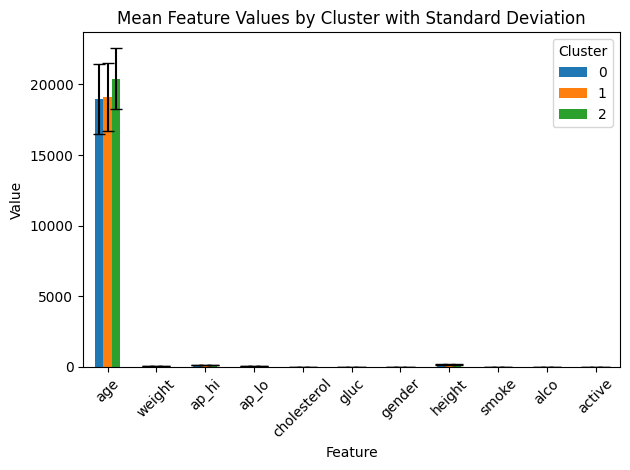

Cardiovascular disease prevalence (%) by cluster:
cardio           0          1
cluster                      
0        66.970536  33.029464
1        54.328358  45.671642
2        22.754491  77.245509


<Figure size 1000x600 with 0 Axes>

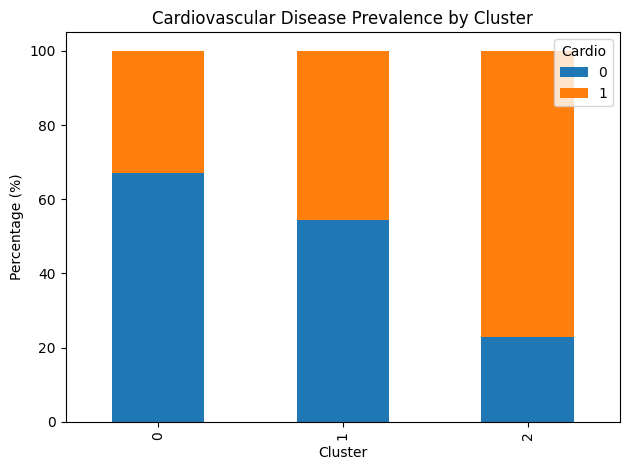

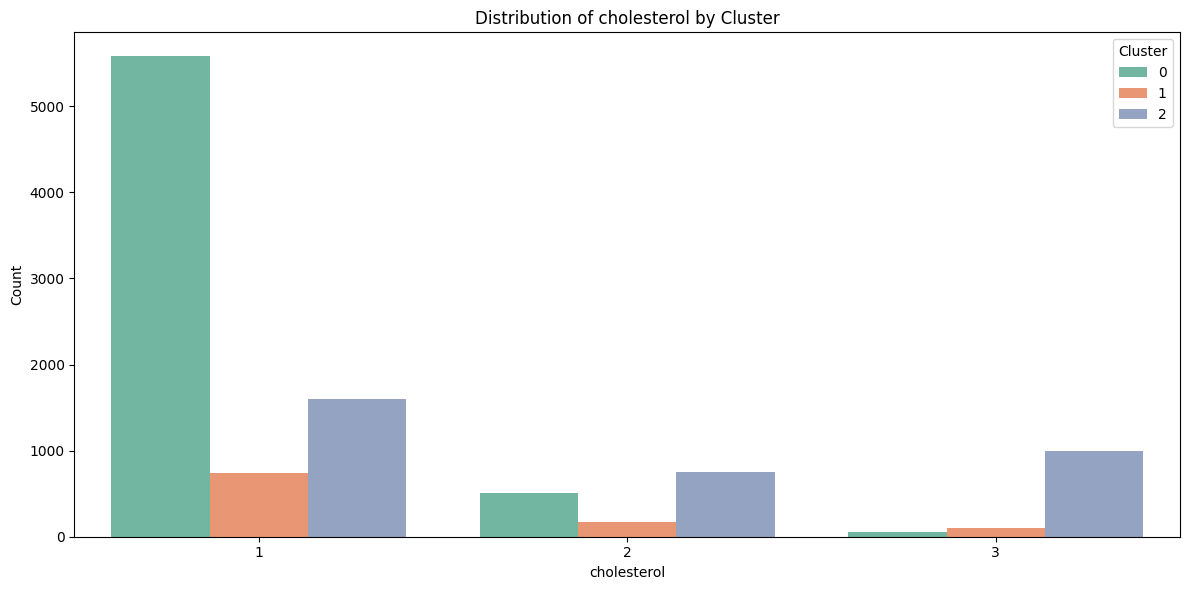

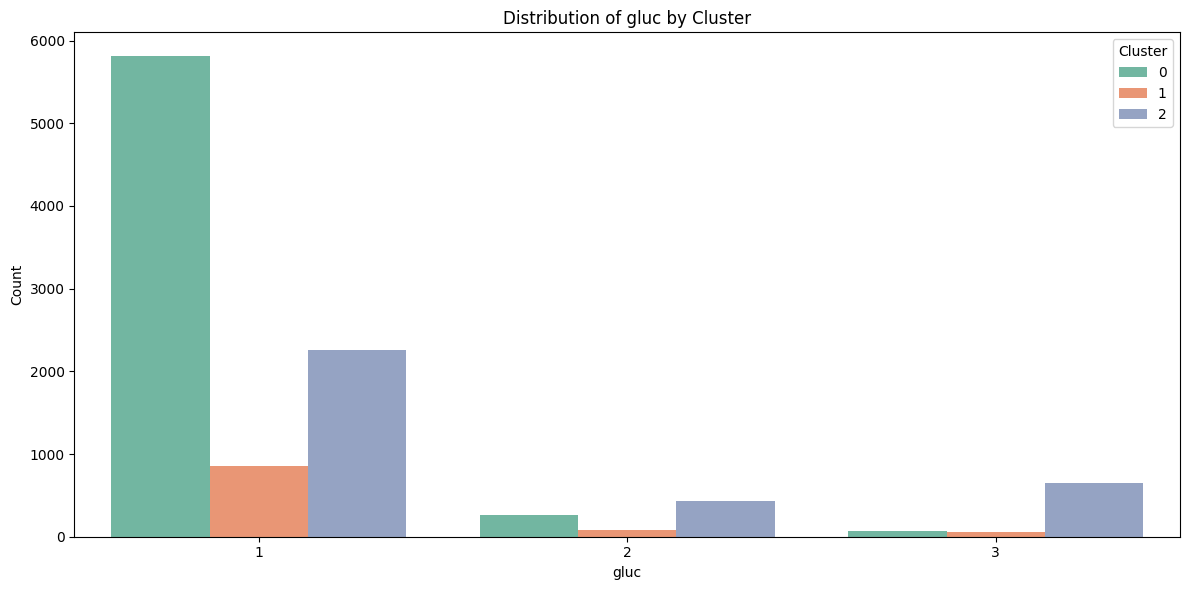

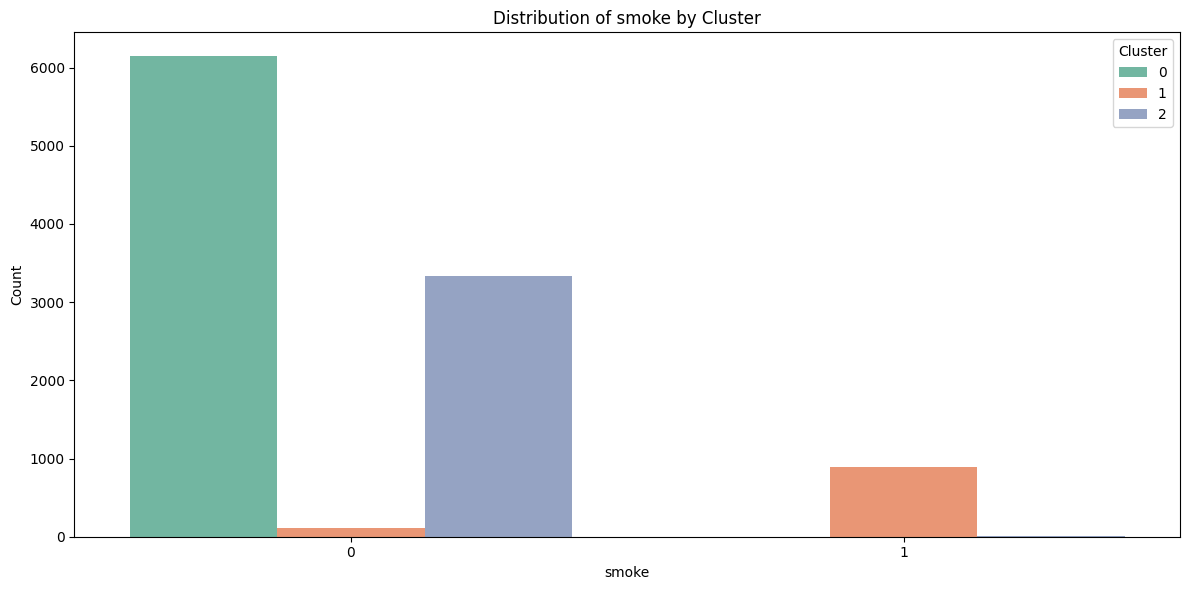

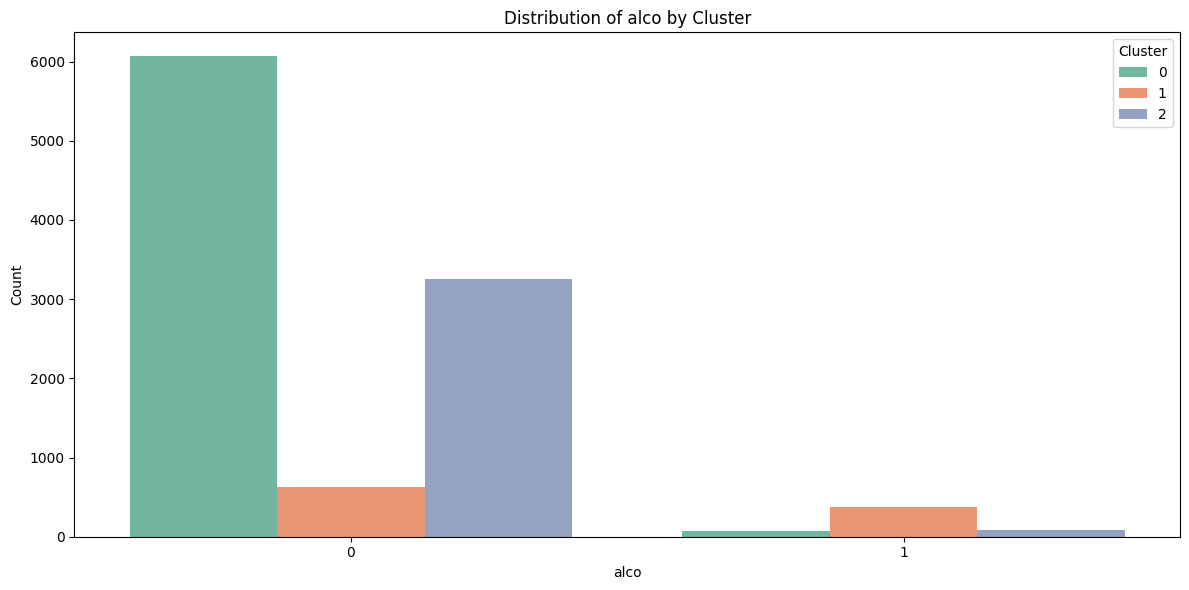

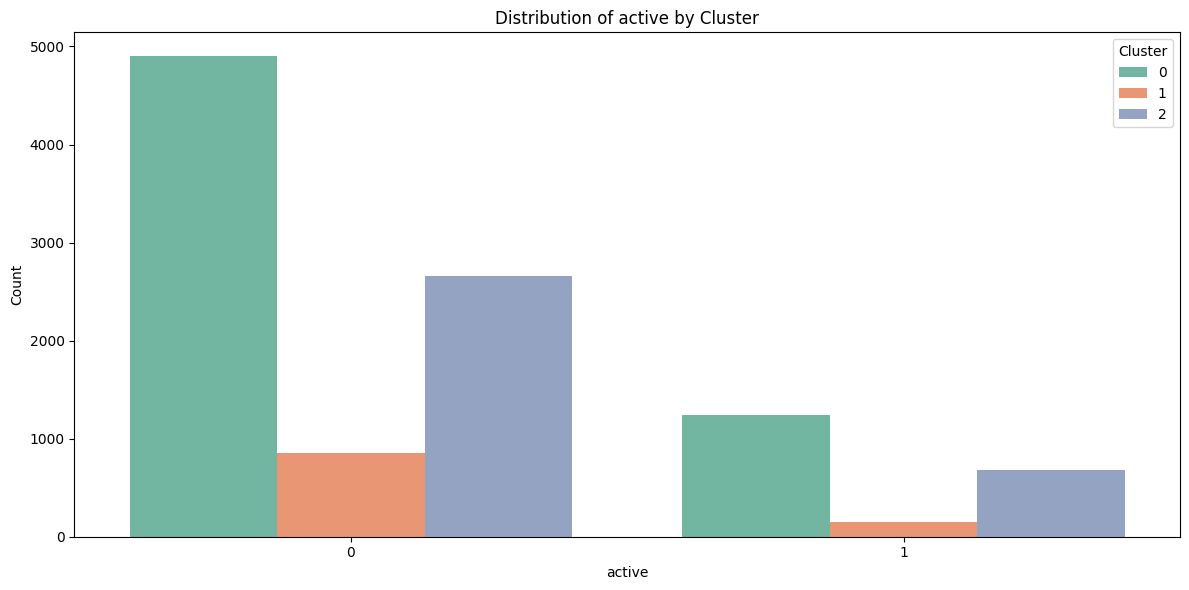

Detailed cluster analysis complete.


In [148]:
# Detailed analysis of clusters
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Calculate summary statistics for each cluster
cluster_stats = df.groupby('cluster')[features].mean()
print("Mean values for each feature by cluster:")
print(cluster_stats)

# Calculate standard deviations for each cluster
cluster_std = df.groupby('cluster')[features].std()
print("\
Standard deviations for each feature by cluster:")
print(cluster_std)

# Visualize the mean values of features for each cluster
plt.figure(figsize=(14, 8))
cluster_stats.T.plot(kind='bar', yerr=cluster_std.T, capsize=4, rot=45)
plt.title('Mean Feature Values by Cluster with Standard Deviation')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Analyze cardiovascular disease prevalence in each cluster
if 'cardio' in df.columns:
    cardio_by_cluster = pd.crosstab(df['cluster'], df['cardio'], normalize='index') * 100
    print("\
Cardiovascular disease prevalence (%) by cluster:")
    print(cardio_by_cluster)
    
    plt.figure(figsize=(10, 6))
    cardio_by_cluster.plot(kind='bar', stacked=True)
    plt.title('Cardiovascular Disease Prevalence by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Percentage (%)')
    plt.legend(title='Cardio')
    plt.tight_layout()
    plt.show()

# Create a radar chart to visualize the profile of each cluster
def radar_chart(df, features, cluster_col='cluster'):
    # Number of variables
    categories = features
    N = len(categories)
    
    # Create a figure
    fig = plt.figure(figsize=(10, 10))
    
    # Calculate angles for each feature
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop
    
    # Initialize the radar chart
    ax = plt.subplot(111, polar=True)
    
    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories, size=12)
    
    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.5", "0.75"], color="grey", size=10)
    plt.ylim(0, 1)
    
    # Get unique clusters
    clusters = sorted(df[cluster_col].unique())
    
    # Plot each cluster
    for i, cluster in enumerate(clusters):
        # Get the values for each cluster
        values = df[df[cluster_col] == cluster][features].mean().values.flatten().tolist()
        
        # Scale the values to [0,1] for better visualization
        min_max_scaler = lambda x: (x - min(x)) / (max(x) - min(x)) if max(x) != min(x) else [0.5] * len(x)
        values = min_max_scaler(values)
        
        values += values[:1]  # Close the loop
        
        # Plot values
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster}')
        ax.fill(angles, values, alpha=0.1)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Cluster Profiles', size=15)
    plt.show()


# Analyze the distribution of categorical variables across clusters
categorical_features = ['cholesterol', 'gluc', 'smoke', 'alco', 'active']
for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    sns.countplot(x=feature, hue='cluster', data=df, palette='Set2')
    plt.title(f'Distribution of {feature} by Cluster')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

print("Detailed cluster analysis complete.")

In [149]:
# Calculate summary statistics for each cluster
cluster_stats = df.groupby('cluster')[features].mean()
print("Mean values for each feature by cluster:")
print(cluster_stats)

Mean values for each feature by cluster:
                  age     weight       ap_hi      ap_lo  cholesterol  \
cluster                                                                
0        18962.332248  69.593261  117.972489  76.833469     1.101579   
1        19117.083582  75.963582  126.518408  81.448756     1.362189   
2        20404.752395  78.156228  139.053593  87.858683     1.817964   

             gluc    gender      height     smoke      alco    active  
cluster                                                                
0        1.066580  1.277389  163.952955  0.000000  0.012535  0.202507  
1        1.202985  1.898507  169.458706  0.884577  0.371144  0.149254  
2        1.516766  1.285629  163.524551  0.002994  0.025749  0.203892  


In [150]:
if 'cardio' in df.columns:
    cardio_by_cluster = pd.crosstab(df['cluster'], df['cardio'], normalize='index') * 100
    print("\
Cardiovascular disease prevalence (%) by cluster:")
    print(cardio_by_cluster)

Cardiovascular disease prevalence (%) by cluster:
cardio           0          1
cluster                      
0        66.970536  33.029464
1        54.328358  45.671642
2        22.754491  77.245509


In [155]:
if 'gender' in df.columns:
    age_by_cluster = pd.crosstab(df['cluster'], df['gender'], normalize='index') * 100
    print("\
Cardiovascular disease prevalence (%) by cluster:")
    print(age_by_cluster)

Cardiovascular disease prevalence (%) by cluster:
gender           1          2
cluster                      
0        72.261110  27.738890
1        10.149254  89.850746
2        71.437126  28.562874
